In [1]:
import pandas as pd
import os

In [2]:
os.getcwd()

'C:\\Users\\Abhijith\\Desktop\\Data Analyst Project\\notebooks'

In [3]:
import os

data_path = "../data/raw"

os.listdir(data_path)

['olist_customers_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'product_category_name_translation.csv']

In [4]:
datasets = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        file_path = os.path.join(data_path, file)
        df = pd.read_csv(file_path)

        table_name = file.replace(".csv", "")
        datasets[table_name] = df

print(datasets.keys())

dict_keys(['olist_customers_dataset', 'olist_geolocation_dataset', 'olist_orders_dataset', 'olist_order_items_dataset', 'olist_order_payments_dataset', 'olist_order_reviews_dataset', 'olist_products_dataset', 'olist_sellers_dataset', 'product_category_name_translation'])


In [5]:
for name, df in datasets.items():
    print(name, df.shape)

olist_customers_dataset (99441, 5)
olist_geolocation_dataset (1000163, 5)
olist_orders_dataset (99441, 8)
olist_order_items_dataset (112650, 7)
olist_order_payments_dataset (103886, 5)
olist_order_reviews_dataset (99224, 7)
olist_products_dataset (32951, 9)
olist_sellers_dataset (3095, 4)
product_category_name_translation (71, 2)


In [6]:
audit = []

for name, df in datasets.items():
    audit.append({
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_values": df.isna().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    })

audit_df = pd.DataFrame(audit)

audit_df

,table,rows,columns,missing_values,duplicate_rows
0,olist_customers_dataset,99441,5,0,0
1,olist_geolocation_dataset,1000163,5,0,261831
2,olist_orders_dataset,99441,8,4908,0
3,olist_order_items_dataset,112650,7,0,0
4,olist_order_payments_dataset,103886,5,0,0
5,olist_order_reviews_dataset,99224,7,145903,0
6,olist_products_dataset,32951,9,2448,0
7,olist_sellers_dataset,3095,4,0,0
8,product_category_name_translation,71,2,0,0


In [7]:
missing_report = []

for name, df in datasets.items():
    for column in df.columns:
        missing_count = df[column].isna().sum()
        
        if missing_count > 0:
            missing_report.append({
                "table": name,
                "column": column,
                "missing_count": missing_count,
                "missing_percentage": round(
                    (missing_count / len(df)) * 100, 2
                )
            })

missing_df = pd.DataFrame(missing_report)

missing_df

,table,column,missing_count,missing_percentage
0,olist_orders_dataset,order_approved_at,160,0.16
1,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
2,olist_orders_dataset,order_delivered_customer_date,2965,2.98
3,olist_order_reviews_dataset,review_comment_title,87656,88.34
4,olist_order_reviews_dataset,review_comment_message,58247,58.70
5,olist_products_dataset,product_category_name,610,1.85
6,olist_products_dataset,product_name_lenght,610,1.85
7,olist_products_dataset,product_description_lenght,610,1.85
8,olist_products_dataset,product_photos_qty,610,1.85
9,olist_products_dataset,product_weight_g,2,0.01


In [8]:
orders = datasets["olist_orders_dataset"]

orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [9]:
products = datasets["olist_products_dataset"]

products.dtypes

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [10]:
products[products["product_category_name"].isna()].head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0


In [11]:
products[products["product_category_name"].isna()].isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [12]:
order_items = datasets["olist_order_items_dataset"]

In [13]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
missing_product_ids = products.loc[
    products["product_category_name"].isna(),
    "product_id"
]

order_items["product_id"].isin(missing_product_ids).sum()

np.int64(1603)

In [15]:
missing_products = products[
    products["product_category_name"].isna()
]

missing_products.shape

(610, 9)

In [16]:
missing_products[[
    "product_id",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]].head(20)

,product_id,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,1400.0,25.0,25.0,25.0


In [17]:
missing_products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [18]:
missing_products.isna().sum(axis=1).value_counts()

4    609
8      1
Name: count, dtype: int64

In [19]:
missing_products[missing_products.isna().sum(axis=1) == 8]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
18851,5eb564652db742ff8f28759cd8d2652a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
bad_product_id = missing_products.loc[
    missing_products.isna().sum(axis=1) == 8,
    "product_id"
].iloc[0]

order_items[order_items["product_id"] == bad_product_id]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
7098,101157d4fae1c9fb74a00a5dee265c25,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 08:02:26,29.0,14.52
9233,1521c6bb7b1028154c8c67cf80fa809f,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:10:16,29.0,16.05
28715,415cfaaaa8cea49f934470548797fed1,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
28716,415cfaaaa8cea49f934470548797fed1,2,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-07 10:35:19,29.0,14.52
39299,595316a07cd3dea9db7adfcc7e247ae7,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-18 04:26:04,39.0,9.27
48424,6e150190fbe04c642a9cf0b80d83ee16,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-06-30 16:45:14,39.0,16.79
48980,6f497c40431d5fb0cfbd6c943dd29215,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-11 05:55:32,29.0,10.96
71134,a2456e7f02197951664897a94c87242d,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-04-06 11:50:09,29.0,24.84
73556,a7a43f469c0d7bdb0a23a82db125aefa,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-08-28 13:15:11,39.0,15.10
82767,bbfc7badbed2f1828e22b6d629201bd4,1,5eb564652db742ff8f28759cd8d2652a,4e922959ae960d389249c378d1c939f5,2017-07-18 04:04:10,39.0,11.85


In [21]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

In [22]:
for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])

In [23]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [24]:
orders[
    orders["order_delivered_customer_date"] <
    orders["order_purchase_timestamp"]
].shape

(0, 8)

In [25]:
orders[
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
].shape

(7827, 8)

In [26]:
orders[
    orders["order_approved_at"] <
    orders["order_purchase_timestamp"]
].shape

(0, 8)

In [27]:
delivered_orders = orders[
    orders["order_delivered_customer_date"].notna()
]

late_orders = delivered_orders[
    delivered_orders["order_delivered_customer_date"] >
    delivered_orders["order_estimated_delivery_date"]
]

late_rate = len(late_orders) / len(delivered_orders) * 100

late_rate

8.112898544715783

In [28]:
orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
].shape

(8, 8)

In [29]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [30]:
delivered_missing_date = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_customer_date"].isna())
]

delivered_missing_date

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [31]:
delivered_missing_date[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19


In [32]:
delivered_missing_date[
    [
        "order_id",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
]

,order_id,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,NaT,2017-12-18
20618,f5dd62b788049ad9fc0526e3ad11a097,NaT,2018-07-16
43834,2ebdfc4f15f23b91474edf87475f108e,NaT,2018-07-30
79263,e69f75a717d64fc5ecdfae42b2e8e086,NaT,2018-07-30
82868,0d3268bad9b086af767785e3f0fc0133,NaT,2018-07-24
92643,2d858f451373b04fb5c984a1cc2defaf,NaT,2017-06-23
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,NaT,2018-06-26
98038,20edc82cf5400ce95e1afacc25798b31,NaT,2018-07-19


In [33]:
orders[
    orders["order_delivered_customer_date"].notna()
    & orders["order_delivered_carrier_date"].notna()
    & (
        orders["order_delivered_customer_date"]
        < orders["order_delivered_carrier_date"]
    )
].shape

(23, 8)

In [34]:
orders[
    orders["order_delivered_customer_date"].notna()
    & orders["order_delivered_carrier_date"].notna()
    & (
        orders["order_delivered_customer_date"]
        < orders["order_delivered_carrier_date"]
    )
][
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].head(20)

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6437,a1abeb653a4d4cd1e142ccb8c82cd069,delivered,2017-07-20 11:20:52,2017-07-21 06:43:14,2017-07-28 16:57:58,2017-07-25 19:32:56,2017-08-14
9553,383aa8b2724fe452d9ccd9934a8c628b,delivered,2017-07-02 20:58:43,2017-07-02 21:10:20,2017-07-07 17:22:41,2017-07-06 14:27:51,2017-07-21
13487,cb1134f9010d242e9515ad1c78ec0c39,delivered,2017-07-16 12:35:34,2017-07-18 06:03:50,2017-07-20 19:22:02,2017-07-19 14:13:28,2017-08-08
14474,dceb62e8fa94b46006c9554fed743df0,delivered,2017-07-20 20:58:05,2017-07-22 11:45:11,2017-08-01 18:23:30,2017-07-26 18:09:10,2017-08-11
19268,5f9d46795c3126674e52becb3a1a517f,delivered,2017-07-18 11:48:20,2017-07-18 12:03:29,2017-07-20 23:03:42,2017-07-20 18:52:41,2017-07-31
21338,8c78d01de3a9009e23d6877a7cc9be20,delivered,2016-10-08 15:36:50,2016-10-08 18:13:44,2016-10-26 11:41:53,2016-10-25 17:51:46,2016-11-30
22520,b27af682321527a6349f1761eb3f360c,delivered,2017-06-14 20:17:04,2017-06-14 20:30:08,2017-06-27 14:51:54,2017-06-26 15:45:35,2017-07-14
25393,1cc3ae63caffff2d6c3ee3e78e074acf,delivered,2017-08-07 21:35:22,2017-08-08 21:45:15,2017-08-10 18:28:56,2017-08-10 18:05:38,2017-08-25
25646,e37f11cae9985ca58f0b56f268720537,delivered,2017-07-26 11:46:34,2017-07-27 10:10:16,2017-08-01 18:17:47,2017-07-31 17:49:56,2017-08-24
27470,fa3e37584f4fdb1ded0e0de700dfcb4e,delivered,2017-07-30 19:32:23,2017-07-30 19:45:09,2017-08-09 18:18:43,2017-08-01 21:13:01,2017-08-18


In [35]:
orders[
    orders["order_approved_at"].notna()
    & (
        orders["order_approved_at"]
        < orders["order_purchase_timestamp"]
    )
].shape

(0, 8)

In [36]:
# 1. Carrier delivery before approval
carrier_before_approval = orders[
    orders["order_delivered_carrier_date"].notna()
    & orders["order_approved_at"].notna()
    & (
        orders["order_delivered_carrier_date"]
        < orders["order_approved_at"]
    )
].shape[0]

# 2. Customer delivery before purchase
customer_before_purchase = orders[
    orders["order_delivered_customer_date"].notna()
    & (
        orders["order_delivered_customer_date"]
        < orders["order_purchase_timestamp"]
    )
].shape[0]

# 3. Customer delivery after estimated date
late_delivery = orders[
    orders["order_delivered_customer_date"].notna()
    & (
        orders["order_delivered_customer_date"]
        > orders["order_estimated_delivery_date"]
    )
].shape[0]

# 4. Delivered orders missing customer delivery date
delivered_missing_customer_date = orders[
    (orders["order_status"] == "delivered")
    & orders["order_delivered_customer_date"].isna()
].shape[0]

print("Carrier before approval:", carrier_before_approval)
print("Customer before purchase:", customer_before_purchase)
print("Customer after estimated date:", late_delivery)
print("Delivered but customer date missing:", delivered_missing_customer_date)

Carrier before approval: 1359
Customer before purchase: 0
Customer after estimated date: 7827
Delivered but customer date missing: 8


In [37]:
# Quick data-quality audit for numeric columns

for name, df in datasets.items():
    print("\n---", name, "---")
    
    numeric_cols = df.select_dtypes(include="number").columns
    
    for col in numeric_cols:
        print(
            col,
            "| negative:", (df[col] < 0).sum(),
            "| zero:", (df[col] == 0).sum()
        )


--- olist_customers_dataset ---
customer_zip_code_prefix | negative: 0 | zero: 0

--- olist_geolocation_dataset ---
geolocation_zip_code_prefix | negative: 0 | zero: 0
geolocation_lat | negative: 998827 | zero: 0
geolocation_lng | negative: 1000160 | zero: 0

--- olist_orders_dataset ---

--- olist_order_items_dataset ---
order_item_id | negative: 0 | zero: 0
price | negative: 0 | zero: 0
freight_value | negative: 0 | zero: 383

--- olist_order_payments_dataset ---
payment_sequential | negative: 0 | zero: 0
payment_installments | negative: 0 | zero: 2
payment_value | negative: 0 | zero: 9

--- olist_order_reviews_dataset ---
review_score | negative: 0 | zero: 0

--- olist_products_dataset ---
product_name_lenght | negative: 0 | zero: 0
product_description_lenght | negative: 0 | zero: 0
product_photos_qty | negative: 0 | zero: 0
product_weight_g | negative: 0 | zero: 4
product_length_cm | negative: 0 | zero: 0
product_height_cm | negative: 0 | zero: 0
product_width_cm | negative: 0 | z

In [38]:
print("ORDER STATUS")
print(orders["order_status"].value_counts())

print("\nPAYMENT TYPES")
payments = datasets["olist_order_payments_dataset"]
print(payments["payment_type"].value_counts())

print("\nREVIEW SCORES")
reviews = datasets["olist_order_reviews_dataset"]
print(reviews["review_score"].value_counts())

ORDER STATUS
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

PAYMENT TYPES
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

REVIEW SCORES
review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64


In [39]:
orders_clean = orders.copy()

In [40]:
orders_clean.shape

(99441, 8)

### Missing Customer Delivery Dates

8 orders have `order_status = delivered` but
`order_delivered_customer_date` is missing.

Decision:
- Do not fill the missing dates.
- Do not delete the orders.
- Keep the values as NaT.
- Exclude these records when calculating metrics that require actual delivery dates.

In [41]:
products_clean = products.copy()

In [42]:
products_clean["product_category_name"].isna().sum()

np.int64(610)

In [43]:
products_clean["product_category_name"].value_counts(dropna=False).head()

product_category_name
cama_mesa_banho          3029
esporte_lazer            2867
moveis_decoracao         2657
beleza_saude             2444
utilidades_domesticas    2335
Name: count, dtype: int64

In [44]:
# ============================================================
# OLIST DATA CLEANING
# ============================================================

# ------------------------------------------------------------
# 1. Create clean copies
# ------------------------------------------------------------

orders_clean = orders.copy()
products_clean = products.copy()
order_items_clean = order_items.copy()

reviews_clean = datasets["olist_order_reviews_dataset"].copy()
payments_clean = datasets["olist_order_payments_dataset"].copy()
customers_clean = datasets["olist_customers_dataset"].copy()
sellers_clean = datasets["olist_sellers_dataset"].copy()
geolocation_clean = datasets["olist_geolocation_dataset"].copy()

category_translation = datasets["product_category_name_translation"].copy()


# ============================================================
# 2. REMOVE EXACT DUPLICATE ROWS
# ============================================================

# Remove exact duplicates only.
# We DO NOT remove duplicates from geolocation because
# multiple coordinates for the same ZIP prefix can be legitimate.

orders_clean = orders_clean.drop_duplicates()
products_clean = products_clean.drop_duplicates()
order_items_clean = order_items_clean.drop_duplicates()
reviews_clean = reviews_clean.drop_duplicates()
payments_clean = payments_clean.drop_duplicates()
customers_clean = customers_clean.drop_duplicates()
sellers_clean = sellers_clean.drop_duplicates()


# ============================================================
# 3. CONVERT ORDER DATE COLUMNS TO DATETIME
# ============================================================

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in date_columns:
    orders_clean[column] = pd.to_datetime(
        orders_clean[column],
        errors="coerce"
    )


# ============================================================
# 4. CONVERT SHIPPING DATE TO DATETIME
# ============================================================

order_items_clean["shipping_limit_date"] = pd.to_datetime(
    order_items_clean["shipping_limit_date"],
    errors="coerce"
)


# ============================================================
# 5. CHECK MISSING PRODUCT CATEGORIES
# ============================================================

print("Missing product categories BEFORE cleaning:")
print(products_clean["product_category_name"].isna().sum())


# ============================================================
# 6. HANDLE MISSING PRODUCT CATEGORY
# ============================================================

# We do NOT invent a category.
# We label missing categories as unknown so the rows remain
# available for analysis.

products_clean["product_category_name"] = (
    products_clean["product_category_name"]
    .fillna("unknown")
)


# ============================================================
# 7. MERGE ENGLISH CATEGORY NAMES
# ============================================================

products_clean = products_clean.merge(
    category_translation,
    on="product_category_name",
    how="left"
)


# ============================================================
# 8. CHECK CATEGORY TRANSLATION
# ============================================================

print("\nProduct columns after translation:")
print(products_clean.columns.tolist())


# ============================================================
# 9. HANDLE MISSING ENGLISH CATEGORY
# ============================================================

products_clean["product_category_name_english"] = (
    products_clean["product_category_name_english"]
    .fillna("unknown")
)


# ============================================================
# 10. CHECK PRODUCT DATA
# ============================================================

print("\nMissing values in products:")
print(products_clean.isna().sum())


# ============================================================
# 11. REVIEW DATA
# ============================================================

print("\nMissing review titles:")
print(reviews_clean["review_comment_title"].isna().sum())

print("\nMissing review messages:")
print(reviews_clean["review_comment_message"].isna().sum())

# Review text is optional.
# We keep missing values because a customer can submit
# a rating without writing a review.


# ============================================================
# 12. CHECK ORDER STATUS
# ============================================================

print("\nOrder status:")
print(orders_clean["order_status"].value_counts())


# ============================================================
# 13. CHECK PAYMENT TYPES
# ============================================================

print("\nPayment types:")
print(payments_clean["payment_type"].value_counts())


# ============================================================
# 14. CHECK REVIEW SCORES
# ============================================================

print("\nReview scores:")
print(reviews_clean["review_score"].value_counts())


# ============================================================
# 15. CREATE DELIVERY DAYS
# ============================================================

orders_clean["delivery_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)


# ============================================================
# 16. CREATE ESTIMATED DELIVERY DAYS
# ============================================================

orders_clean["estimated_delivery_days"] = (
    orders_clean["order_estimated_delivery_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / (24 * 60 * 60)


# ============================================================
# 17. CREATE LATE DELIVERY FLAG
# ============================================================

orders_clean["is_late"] = (
    orders_clean["order_delivered_customer_date"]
    > orders_clean["order_estimated_delivery_date"]
)


# ============================================================
# 18. CREATE DELIVERY STATUS
# ============================================================

orders_clean["delivery_status"] = "not_delivered"

orders_clean.loc[
    orders_clean["order_status"] == "delivered",
    "delivery_status"
] = "delivered"


orders_clean.loc[
    orders_clean["is_late"] == True,
    "delivery_status"
] = "late"


# ============================================================
# 19. CHECK DELIVERY DATA
# ============================================================

print("\nDelivery status:")
print(orders_clean["delivery_status"].value_counts())


# ============================================================
# 20. CHECK IMPOSSIBLE DELIVERY DATES
# ============================================================

invalid_delivery = orders_clean[
    orders_clean["order_delivered_customer_date"].notna()
    &
    orders_clean["order_purchase_timestamp"].notna()
    &
    (
        orders_clean["order_delivered_customer_date"]
        <
        orders_clean["order_purchase_timestamp"]
    )
]

print("\nImpossible delivery dates:", len(invalid_delivery))


# ============================================================
# 21. CHECK NEGATIVE DELIVERY DAYS
# ============================================================

print(
    "\nNegative delivery days:",
    (orders_clean["delivery_days"] < 0).sum()
)


# ============================================================
# 22. CHECK NEGATIVE PRICES
# ============================================================

print(
    "\nNegative prices:",
    (order_items_clean["price"] < 0).sum()
)

print(
    "Negative freight values:",
    (order_items_clean["freight_value"] < 0).sum()
)


# ============================================================
# 23. CHECK PRODUCT NUMERIC VALUES
# ============================================================

numeric_product_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in numeric_product_columns:
    print(
        column,
        "negative:",
        (products_clean[column] < 0).sum()
    )


# ============================================================
# 24. FINAL DATASET SIZES
# ============================================================

print("\n==============================")
print("FINAL DATASET SIZES")
print("==============================")

print("Orders:", orders_clean.shape)
print("Products:", products_clean.shape)
print("Order Items:", order_items_clean.shape)
print("Reviews:", reviews_clean.shape)
print("Payments:", payments_clean.shape)
print("Customers:", customers_clean.shape)
print("Sellers:", sellers_clean.shape)


# ============================================================
# 25. FINAL MISSING VALUE SUMMARY
# ============================================================

print("\n==============================")
print("FINAL MISSING VALUES")
print("==============================")

print("\nORDERS")
print(orders_clean.isna().sum())

print("\nPRODUCTS")
print(products_clean.isna().sum())

print("\nORDER ITEMS")
print(order_items_clean.isna().sum())

print("\nREVIEWS")
print(reviews_clean.isna().sum())


print("\n==============================")
print("CLEANING COMPLETED")
print("==============================")

Missing product categories BEFORE cleaning:
610

Product columns after translation:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english']

Missing values in products:
product_id                         0
product_category_name              0
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english      0
dtype: int64

Missing review titles:
87656

Missing review messages:
58247

Order status:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dty

In [45]:
# Create the main analytical dataset

orders_analysis = orders_clean.copy()

orders_analysis = orders_analysis.merge(
    order_items_clean,
    on="order_id",
    how="left"
)

orders_analysis = orders_analysis.merge(
    products_clean[
        [
            "product_id",
            "product_category_name_english",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

orders_analysis = orders_analysis.merge(
    sellers_clean,
    on="seller_id",
    how="left"
)

orders_analysis = orders_analysis.merge(
    customers_clean,
    on="customer_id",
    how="left"
)

orders_analysis = orders_analysis.merge(
    payments_clean,
    on="order_id",
    how="left"
)

orders_analysis = orders_analysis.merge(
    reviews_clean[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

print("Analytical dataset shape:", orders_analysis.shape)

Analytical dataset shape: (119143, 35)


In [46]:
orders_analysis["order_id"].nunique()

99441

In [47]:
orders_analysis["product_id"].nunique()

32951

In [48]:
orders_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,estimated_delivery_days,...,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,...,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,...,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,15.544063,...,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,19.137766,...,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,26.639711,...,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12,5.0


In [50]:
orders_analysis.isna().sum().sort_values(ascending=False).head(15)

order_delivered_customer_date    3421
delivery_days                    3421
order_delivered_carrier_date     2086
review_score                      997
product_length_cm                 853
product_weight_g                  853
product_height_cm                 853
product_width_cm                  853
seller_state                      833
seller_zip_code_prefix            833
seller_city                       833
product_category_name_english     833
price                             833
product_id                        833
freight_value                     833
dtype: int64

In [49]:
# ============================================================
# BUSINESS PERFORMANCE ANALYSIS
# ============================================================

# 1. Overall Business Metrics
total_revenue = orders_analysis["price"].sum()
total_freight = orders_analysis["freight_value"].sum()
total_orders = orders_analysis["order_id"].nunique()
total_customers = orders_analysis["customer_id"].nunique()
total_products = orders_analysis["product_id"].nunique()

average_order_value = total_revenue / total_orders


print("=" * 55)
print("OVERALL BUSINESS PERFORMANCE")
print("=" * 55)

print(f"Total Revenue      : {total_revenue:,.2f}")
print(f"Total Freight      : {total_freight:,.2f}")
print(f"Total Orders       : {total_orders:,}")
print(f"Total Customers    : {total_customers:,}")
print(f"Total Products     : {total_products:,}")
print(f"Average Order Value: {average_order_value:,.2f}")


# ============================================================
# 2. ORDER STATUS ANALYSIS
# ============================================================

order_status_analysis = (
    orders_analysis
    .groupby("order_status")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .sort_values("orders", ascending=False)
)

print("\n" + "=" * 55)
print("ORDER STATUS ANALYSIS")
print("=" * 55)

print(order_status_analysis)


# ============================================================
# 3. PRODUCT CATEGORY PERFORMANCE
# ============================================================

category_analysis = (
    orders_analysis
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("product_id", "nunique"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        average_price=("price", "mean")
    )
    .sort_values("revenue", ascending=False)
)

print("\n" + "=" * 55)
print("TOP 15 PRODUCT CATEGORIES BY REVENUE")
print("=" * 55)

print(category_analysis.head(15))


# ============================================================
# 4. TOP PRODUCTS BY REVENUE
# ============================================================

product_analysis = (
    orders_analysis
    .groupby("product_id")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("product_id", "count"),
        revenue=("price", "sum"),
        average_price=("price", "mean")
    )
    .sort_values("revenue", ascending=False)
)

print("\n" + "=" * 55)
print("TOP 15 PRODUCTS BY REVENUE")
print("=" * 55)

print(product_analysis.head(15))


# ============================================================
# 5. SELLER PERFORMANCE
# ============================================================

seller_analysis = (
    orders_analysis
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("product_id", "count"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        average_price=("price", "mean")
    )
    .sort_values("revenue", ascending=False)
)

print("\n" + "=" * 55)
print("TOP 15 SELLERS BY REVENUE")
print("=" * 55)

print(seller_analysis.head(15))


# ============================================================
# 6. DELIVERY PERFORMANCE
# ============================================================

delivery_analysis = (
    orders_analysis
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_delivery_days=("delivery_days", "mean")
    )
    .sort_values("orders", ascending=False)
)

print("\n" + "=" * 55)
print("DELIVERY PERFORMANCE")
print("=" * 55)

print(delivery_analysis)


# ============================================================
# 7. CUSTOMER SATISFACTION
# ============================================================

review_analysis = (
    orders_analysis
    .groupby("review_score")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .sort_index()
)

print("\n" + "=" * 55)
print("CUSTOMER REVIEW ANALYSIS")
print("=" * 55)

print(review_analysis)


# ============================================================
# 8. LATE DELIVERY VS REVIEW SCORE
# ============================================================

late_review_analysis = (
    orders_analysis
    .dropna(subset=["review_score"])
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean")
    )
)

print("\n" + "=" * 55)
print("DELIVERY STATUS VS CUSTOMER SATISFACTION")
print("=" * 55)

print(late_review_analysis)

OVERALL BUSINESS PERFORMANCE
Total Revenue      : 14,273,699.65
Total Freight      : 2,370,031.65
Total Orders       : 99,441
Total Customers    : 99,441
Total Products     : 32,951
Average Order Value: 143.54

ORDER STATUS ANALYSIS
              orders      revenue
order_status                     
delivered      96478  13876471.73
shipped         1107    166292.96
canceled         625    101825.85
unavailable      609      2007.69
invoiced         314     63402.01
processing       301     63489.81
created            5         0.00
approved           2       209.60

TOP 15 PRODUCT CATEGORIES BY REVENUE
                               orders  products_sold     revenue    freight  \
product_category_name_english                                                 
health_beauty                    8836           2444  1301947.97  189449.79   
watches_gifts                    5624           1329  1254322.95  104522.64   
bed_bath_table                   9417           3029  1107249.09  220412.

In [50]:
# ============================================================
# SALES & CUSTOMER TREND ANALYSIS
# ============================================================

# Make sure purchase date is available
orders_analysis["order_date"] = (
    orders_analysis["order_purchase_timestamp"].dt.date
)

orders_analysis["order_month"] = (
    orders_analysis["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)


# ============================================================
# 1. MONTHLY SALES PERFORMANCE
# ============================================================

monthly_sales = (
    orders_analysis
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
    .reset_index()
)

monthly_sales["average_order_value"] = (
    monthly_sales["revenue"] /
    monthly_sales["orders"]
)

print("=" * 60)
print("MONTHLY SALES PERFORMANCE")
print("=" * 60)

print(monthly_sales)


# ============================================================
# 2. TOP 10 MONTHS BY REVENUE
# ============================================================

top_months = (
    monthly_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 MONTHS BY REVENUE")
print("=" * 60)

print(top_months)


# ============================================================
# 3. CATEGORY REVENUE SHARE
# ============================================================

category_analysis["revenue_share_pct"] = (
    category_analysis["revenue"] /
    category_analysis["revenue"].sum()
) * 100

top_categories = (
    category_analysis
    .sort_values("revenue", ascending=False)
    .head(10)
)

print("\n" + "=" * 60)
print("TOP 10 CATEGORIES + REVENUE SHARE")
print("=" * 60)

print(
    top_categories[
        [
            "orders",
            "products_sold",
            "revenue",
            "revenue_share_pct",
            "average_price"
        ]
    ]
)


# ============================================================
# 4. CUSTOMER ORDER FREQUENCY
# ============================================================

customer_orders = (
    orders_analysis
    .groupby("customer_id")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
)

print("\n" + "=" * 60)
print("CUSTOMER ORDER FREQUENCY")
print("=" * 60)

print(customer_orders["orders"].value_counts().head(10))


# ============================================================
# 5. REPEAT CUSTOMERS
# ============================================================

repeat_customers = (
    customer_orders["orders"] > 1
).sum()

one_time_customers = (
    customer_orders["orders"] == 1
).sum()

total_customers = len(customer_orders)

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("\n" + "=" * 60)
print("CUSTOMER RETENTION")
print("=" * 60)

print(f"Total Customers       : {total_customers:,}")
print(f"One-time Customers    : {one_time_customers:,}")
print(f"Repeat Customers      : {repeat_customers:,}")
print(f"Repeat Customer Rate  : {repeat_customer_rate:.2f}%")


# ============================================================
# 6. HIGH VALUE CUSTOMERS
# ============================================================

top_customers = (
    customer_orders
    .sort_values("revenue", ascending=False)
    .head(20)
)

print("\n" + "=" * 60)
print("TOP 20 CUSTOMERS BY REVENUE")
print("=" * 60)

print(top_customers)


# ============================================================
# 7. REVIEW DISTRIBUTION %
# ============================================================

review_distribution = (
    orders_analysis["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\n" + "=" * 60)
print("REVIEW SCORE DISTRIBUTION (%)")
print("=" * 60)

print(review_distribution)


# ============================================================
# 8. LATE DELIVERY RATE
# ============================================================

delivery_counts = (
    orders_analysis
    .groupby("delivery_status")["order_id"]
    .nunique()
)

total_delivery_orders = delivery_counts.sum()

late_delivery_rate = (
    delivery_counts.get("late", 0) /
    total_delivery_orders
) * 100

not_delivered_rate = (
    delivery_counts.get("not_delivered", 0) /
    total_delivery_orders
) * 100

print("\n" + "=" * 60)
print("DELIVERY RATES")
print("=" * 60)

print(f"Late Delivery Rate     : {late_delivery_rate:.2f}%")
print(f"Not Delivered Rate     : {not_delivered_rate:.2f}%")


# ============================================================
# 9. CATEGORY + DELIVERY PERFORMANCE
# ============================================================

category_delivery = (
    orders_analysis
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        late_orders=("is_late", "sum"),
        average_review=("review_score", "mean")
    )
)

category_delivery["late_rate_pct"] = (
    category_delivery["late_orders"] /
    category_delivery["orders"]
) * 100

category_delivery = (
    category_delivery
    .sort_values("revenue", ascending=False)
)

print("\n" + "=" * 60)
print("CATEGORY DELIVERY PERFORMANCE")
print("=" * 60)

print(category_delivery.head(15))


# ============================================================
# 10. SAVE ANALYSIS TABLES
# ============================================================

analysis_tables = {
    "monthly_sales": monthly_sales,
    "category_analysis": category_analysis,
    "seller_analysis": seller_analysis,
    "delivery_analysis": delivery_analysis,
    "review_analysis": review_analysis,
    "customer_orders": customer_orders,
    "category_delivery": category_delivery
}

print("\n" + "=" * 60)
print("ANALYSIS COMPLETED")
print("=" * 60)

print("Tables created:")
for table_name in analysis_tables:
    print("-", table_name)

MONTHLY SALES PERFORMANCE
   order_month  orders     revenue    freight  average_order_value
0      2016-09       4      267.36      87.39            66.840000
1      2016-10     324    51068.92    7661.93           157.620123
2      2016-12       1       10.90       8.72            10.900000
3      2017-01     800   129895.32   18134.79           162.369150
4      2017-02    1780   262013.86   41634.45           147.198798
5      2017-03    2682   398117.44   61661.20           148.440507
6      2017-04    2404   392595.36   57112.45           163.309218
7      2017-05    3700   549226.84   85535.38           148.439686
8      2017-06    3245   456867.47   74184.59           140.791208
9      2017-07    4026   536906.96   94434.61           133.359901
10     2017-08    4331   606026.98  100141.97           139.927726
11     2017-09    4285   665047.38  102278.32           155.203589
12     2017-10    4631   697457.32  111454.01           150.606202
13     2017-11    7544  1055072.10  

In [51]:
# ============================================================
# FINAL BUSINESS INSIGHTS
# ============================================================

# 1. Overall metrics
total_revenue = orders_analysis["price"].sum()
total_freight = orders_analysis["freight_value"].sum()
total_orders = orders_analysis["order_id"].nunique()
total_products = orders_analysis["product_id"].nunique()

aov = total_revenue / total_orders


# 2. Delivery metrics
delivery_summary = (
    orders_analysis
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        average_review=("review_score", "mean"),
        average_delivery_days=("delivery_days", "mean")
    )
)

delivery_summary["order_share_pct"] = (
    delivery_summary["orders"] /
    delivery_summary["orders"].sum()
) * 100


# 3. Category performance
category_summary = (
    orders_analysis
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        average_price=("price", "mean"),
        average_review=("review_score", "mean"),
        late_orders=("is_late", "sum")
    )
)

category_summary["late_rate_pct"] = (
    category_summary["late_orders"] /
    category_summary["orders"]
) * 100

category_summary["revenue_share_pct"] = (
    category_summary["revenue"] /
    category_summary["revenue"].sum()
) * 100


# 4. Monthly performance
monthly_summary = (
    orders_analysis
    .groupby("order_month")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum")
    )
    .reset_index()
)

monthly_summary["aov"] = (
    monthly_summary["revenue"] /
    monthly_summary["orders"]
)


# 5. Review / satisfaction
review_summary = (
    orders_analysis
    .groupby("review_score")
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum")
    )
    .reset_index()
)

review_summary["order_share_pct"] = (
    review_summary["orders"] /
    review_summary["orders"].sum()
) * 100


# ============================================================
# PRINT FINAL KPI SUMMARY
# ============================================================

print("=" * 70)
print("FINAL BUSINESS KPI SUMMARY")
print("=" * 70)

print(f"Total Revenue       : {total_revenue:,.2f}")
print(f"Total Freight       : {total_freight:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Total Products      : {total_products:,}")
print(f"Average Order Value : {aov:,.2f}")

print("\n" + "=" * 70)
print("DELIVERY PERFORMANCE")
print("=" * 70)

print(delivery_summary.round(2))

print("\n" + "=" * 70)
print("TOP 10 CATEGORIES")
print("=" * 70)

print(
    category_summary
    .sort_values("revenue", ascending=False)
    .head(10)
    .round(2)
)

print("\n" + "=" * 70)
print("TOP 10 MONTHS")
print("=" * 70)

print(
    monthly_summary
    .sort_values("revenue", ascending=False)
    .head(10)
    .round(2)
)

print("\n" + "=" * 70)
print("REVIEW PERFORMANCE")
print("=" * 70)

print(review_summary.round(2))

print("\n" + "=" * 70)
print("FINAL ANALYTICS TABLES READY")
print("=" * 70)

print("""
1. monthly_summary
2. category_summary
3. delivery_summary
4. review_summary

These tables will be used for:
→ Business insights
→ Power BI dashboard
→ Executive recommendations
→ Resume/project presentation
""")

FINAL BUSINESS KPI SUMMARY
Total Revenue       : 14,273,699.65
Total Freight       : 2,370,031.65
Total Orders        : 99,441
Total Products      : 32,951
Average Order Value : 143.54

DELIVERY PERFORMANCE
                 orders      revenue  average_review  average_delivery_days  \
delivery_status                                                               
delivered         88652  12664928.83            4.21                  10.88   
late               7827   1211572.89            2.55                  31.44   
not_delivered      2962    397197.93            1.75                  16.61   

                 order_share_pct  
delivery_status                   
delivered                  89.15  
late                        7.87  
not_delivered               2.98  

TOP 10 CATEGORIES
                               orders     revenue  average_price  \
product_category_name_english                                      
health_beauty                    8836  1301947.97         129.78   

In [52]:
# ============================================================
# FACT SALES TABLE
# Grain = One row per order item
# ============================================================

fact_sales = order_items_clean.copy()

# Add order information
fact_sales = fact_sales.merge(
    orders_clean[
        [
            "order_id",
            "customer_id",
            "order_status",
            "order_purchase_timestamp",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_days",
            "is_late",
            "delivery_status"
        ]
    ],
    on="order_id",
    how="left"
)

# Add product information
fact_sales = fact_sales.merge(
    products_clean[
        [
            "product_id",
            "product_category_name_english",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left"
)

# Add seller information
fact_sales = fact_sales.merge(
    sellers_clean,
    on="seller_id",
    how="left"
)

print("=" * 60)
print("FACT SALES TABLE")
print("=" * 60)

print("Shape:", fact_sales.shape)
print("Unique orders:", fact_sales["order_id"].nunique())
print("Unique products:", fact_sales["product_id"].nunique())
print("Unique sellers:", fact_sales["seller_id"].nunique())

print("\nColumns:")
print(fact_sales.columns.tolist())

FACT SALES TABLE
Shape: (112650, 23)
Unique orders: 98666
Unique products: 32951
Unique sellers: 3095

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'is_late', 'delivery_status', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [53]:
# ============================================================
# KPI LAYER
# ============================================================

# ------------------------------------------------------------
# 1. Total Revenue
# ------------------------------------------------------------

total_revenue = fact_sales["price"].sum()


# ------------------------------------------------------------
# 2. Total Freight
# ------------------------------------------------------------

total_freight = fact_sales["freight_value"].sum()


# ------------------------------------------------------------
# 3. Total Orders
# ------------------------------------------------------------

total_orders = fact_sales["order_id"].nunique()


# ------------------------------------------------------------
# 4. Total Customers
# ------------------------------------------------------------

total_customers = fact_sales["customer_id"].nunique()


# ------------------------------------------------------------
# 5. Total Products
# ------------------------------------------------------------

total_products = fact_sales["product_id"].nunique()


# ------------------------------------------------------------
# 6. Total Sellers
# ------------------------------------------------------------

total_sellers = fact_sales["seller_id"].nunique()


# ------------------------------------------------------------
# 7. Average Order Value
# ------------------------------------------------------------

order_revenue = (
    fact_sales
    .groupby("order_id")["price"]
    .sum()
)

average_order_value = order_revenue.mean()


# ------------------------------------------------------------
# 8. Average Item Price
# ------------------------------------------------------------

average_item_price = fact_sales["price"].mean()


# ------------------------------------------------------------
# 9. Average Freight per Order
# ------------------------------------------------------------

order_freight = (
    fact_sales
    .groupby("order_id")["freight_value"]
    .sum()
)

average_freight_per_order = order_freight.mean()


# ------------------------------------------------------------
# 10. Late Order Rate
# ------------------------------------------------------------

order_status_analysis = (
    fact_sales[
        ["order_id", "is_late", "delivery_status"]
    ]
    .drop_duplicates("order_id")
)

late_order_rate = (
    order_status_analysis["is_late"].mean() * 100
)


# ------------------------------------------------------------
# 11. Average Delivery Days
# ------------------------------------------------------------

average_delivery_days = (
    fact_sales
    .groupby("order_id")["delivery_days"]
    .first()
    .mean()
)


# ------------------------------------------------------------
# Display KPIs
# ------------------------------------------------------------

print("=" * 60)
print("BUSINESS KPI SUMMARY")
print("=" * 60)

print(f"Total Revenue       : ${total_revenue:,.2f}")
print(f"Total Freight       : ${total_freight:,.2f}")
print(f"Total Orders        : {total_orders:,}")
print(f"Total Customers     : {total_customers:,}")
print(f"Total Products      : {total_products:,}")
print(f"Total Sellers       : {total_sellers:,}")
print(f"Average Order Value : ${average_order_value:,.2f}")
print(f"Average Item Price  : ${average_item_price:,.2f}")
print(f"Avg Freight/Order   : ${average_freight_per_order:,.2f}")
print(f"Late Order Rate     : {late_order_rate:.2f}%")
print(f"Avg Delivery Days   : {average_delivery_days:.2f}")

BUSINESS KPI SUMMARY
Total Revenue       : $13,591,643.70
Total Freight       : $2,251,909.54
Total Orders        : 98,666
Total Customers     : 98,666
Total Products      : 32,951
Total Sellers       : 3,095
Average Order Value : $137.75
Average Item Price  : $120.65
Avg Freight/Order   : $22.82
Late Order Rate     : 7.93%
Avg Delivery Days   : 12.56


In [54]:
# ============================================================
# MONTHLY SALES ANALYSIS
# ============================================================

# Create month column
fact_sales["order_month"] = (
    fact_sales["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly revenue
monthly_sales = (
    fact_sales
    .groupby("order_month")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count")
    )
    .reset_index()
)

# Average order value
monthly_sales["average_order_value"] = (
    monthly_sales["revenue"] /
    monthly_sales["orders"]
)

# Freight as percentage of revenue
monthly_sales["freight_percentage"] = (
    monthly_sales["freight"] /
    monthly_sales["revenue"] * 100
)

# Display
print("=" * 80)
print("MONTHLY SALES PERFORMANCE")
print("=" * 80)

print(monthly_sales.to_string(index=False))

MONTHLY SALES PERFORMANCE
order_month    revenue   freight  orders  items  average_order_value  freight_percentage
    2016-09     267.36     87.39       3      6            89.120000           32.686266
    2016-10   49507.66   7301.18     308    363           160.739156           14.747576
    2016-12      10.90      8.72       1      1            10.900000           80.000000
    2017-01  120312.87  16875.62     789    955           152.487795           14.026446
    2017-02  247303.02  38977.60    1733   1951           142.702262           15.761069
    2017-03  374344.30  57704.29    2641   3000           141.743393           15.414764
    2017-04  359927.23  52495.01    2391   2684           150.534182           14.584895
    2017-05  506071.14  80119.81    3660   4136           138.270803           15.831729
    2017-06  433038.60  69924.44    3217   3583           134.609450           16.147392
    2017-07  498031.48  86940.14    3969   4519           125.480343           17.45

In [55]:
# ============================================================
# MONTHLY GROWTH ANALYSIS
# ============================================================

monthly_sales["revenue_growth_pct"] = (
    monthly_sales["revenue"]
    .pct_change() * 100
)

monthly_sales["order_growth_pct"] = (
    monthly_sales["orders"]
    .pct_change() * 100
)

monthly_sales["aov_growth_pct"] = (
    monthly_sales["average_order_value"]
    .pct_change() * 100
)

print("=" * 80)
print("MONTHLY GROWTH ANALYSIS")
print("=" * 80)

print(
    monthly_sales[
        [
            "order_month",
            "revenue",
            "orders",
            "average_order_value",
            "revenue_growth_pct",
            "order_growth_pct",
            "aov_growth_pct"
        ]
    ].to_string(index=False)
)

MONTHLY GROWTH ANALYSIS
order_month    revenue  orders  average_order_value  revenue_growth_pct  order_growth_pct  aov_growth_pct
    2016-09     267.36       3            89.120000                 NaN               NaN             NaN
    2016-10   49507.66     308           160.739156        1.841723e+04      10166.666667       80.362608
    2016-12      10.90       1            10.900000       -9.997798e+01        -99.675325      -93.218827
    2017-01  120312.87     789           152.487795        1.103688e+06      78800.000000     1298.970593
    2017-02  247303.02    1733           142.702262        1.055499e+02        119.645120       -6.417256
    2017-03  374344.30    2641           141.743393        5.137069e+01         52.394691       -0.671937
    2017-04  359927.23    2391           150.534182       -3.851286e+00         -9.466111        6.201904
    2017-05  506071.14    3660           138.270803        4.060374e+01         53.074028       -8.146574
    2017-06  433038.60

In [56]:
# ============================================================
# TOP REVENUE GROWTH MONTHS
# ============================================================

growth_analysis = monthly_sales[
    monthly_sales["orders"] >= 500
].copy()

top_growth_months = (
    growth_analysis
    .sort_values("revenue_growth_pct", ascending=False)
    .head(10)
)

print("\n" + "=" * 80)
print("TOP 10 REVENUE GROWTH MONTHS")
print("=" * 80)

print(
    top_growth_months[
        [
            "order_month",
            "revenue",
            "orders",
            "average_order_value",
            "revenue_growth_pct"
        ]
    ].to_string(index=False)
)


TOP 10 REVENUE GROWTH MONTHS
order_month    revenue  orders  average_order_value  revenue_growth_pct
    2017-01  120312.87     789           152.487795        1.103688e+06
    2017-02  247303.02    1733           142.702262        1.055499e+02
    2017-11 1010271.37    7451           135.588695        5.209904e+01
    2017-03  374344.30    2641           141.743393        5.137069e+01
    2017-05  506071.14    3660           138.270803        4.060374e+01
    2018-01  950030.36    7220           131.583152        2.770699e+01
    2018-03  983213.44    7188           136.785398        1.646982e+01
    2017-08  573971.68    4293           133.699436        1.524807e+01
    2017-07  498031.48    3969           125.480343        1.500857e+01
    2017-09  624401.69    4243           147.160427        8.786150e+00


In [57]:
# ============================================================
# PRODUCT CATEGORY PERFORMANCE
# ============================================================

category_sales = (
    fact_sales
    .groupby("product_category_name_english")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        sellers=("seller_id", "nunique")
    )
    .reset_index()
)

# Average order value
category_sales["average_order_value"] = (
    category_sales["revenue"] /
    category_sales["orders"]
)

# Freight as % of revenue
category_sales["freight_percentage"] = (
    category_sales["freight"] /
    category_sales["revenue"] * 100
)

# Revenue share
category_sales["revenue_share"] = (
    category_sales["revenue"] /
    category_sales["revenue"].sum() * 100
)

# Sort by revenue
category_sales = category_sales.sort_values(
    "revenue",
    ascending=False
)

print("=" * 100)
print("PRODUCT CATEGORY PERFORMANCE")
print("=" * 100)

print(category_sales.to_string(index=False))

PRODUCT CATEGORY PERFORMANCE
          product_category_name_english    revenue   freight  orders  items  sellers  average_order_value  freight_percentage  revenue_share
                          health_beauty 1258681.34 182566.73    8836   9670      492           142.449224           14.504603       9.260700
                          watches_gifts 1205005.68 100535.93    5624   5991      101           214.261323            8.343191       8.865783
                         bed_bath_table 1036988.68 204693.04    9417  11115      196           110.118794           19.739178       7.629605
                         sports_leisure  988048.97 168607.51    7720   8641      481           127.985618           17.064692       7.269533
                  computers_accessories  911954.32 147318.08    6689   7827      287           136.336421           16.154107       6.709669
                        furniture_decor  729762.49 172749.30    6449   8334      370           113.159015           23.671989

In [58]:
# ============================================================
# TOP 10 CATEGORIES BY ORDER VOLUME
# ============================================================

top_categories_orders = (
    category_sales
    .sort_values("orders", ascending=False)
    .head(10)
)

print("=" * 80)
print("TOP 10 CATEGORIES BY ORDER VOLUME")
print("=" * 80)

print(
    top_categories_orders[
        [
            "product_category_name_english",
            "orders",
            "revenue",
            "average_order_value",
            "revenue_share"
        ]
    ].to_string(index=False)
)

TOP 10 CATEGORIES BY ORDER VOLUME
product_category_name_english  orders    revenue  average_order_value  revenue_share
               bed_bath_table    9417 1036988.68           110.118794       7.629605
                health_beauty    8836 1258681.34           142.449224       9.260700
               sports_leisure    7720  988048.97           127.985618       7.269533
        computers_accessories    6689  911954.32           136.336421       6.709669
              furniture_decor    6449  729762.49           113.159015       5.369200
                   housewares    5884  632248.66           107.452186       4.651745
                watches_gifts    5624 1205005.68           214.261323       8.865783
                    telephony    4199  323667.53            77.082050       2.381372
                         auto    3897  592720.11           152.096513       4.360916
                         toys    3886  483946.60           124.535924       3.560619


In [59]:
# ============================================================
# TOP 10 CATEGORIES BY ORDER VOLUME
# ============================================================

top_categories_orders = (
    category_sales
    .sort_values("orders", ascending=False)
    .head(10)
)

print("=" * 80)
print("TOP 10 CATEGORIES BY ORDER VOLUME")
print("=" * 80)

print(
    top_categories_orders[
        [
            "product_category_name_english",
            "orders",
            "revenue",
            "average_order_value",
            "revenue_share"
        ]
    ].to_string(index=False)
)

TOP 10 CATEGORIES BY ORDER VOLUME
product_category_name_english  orders    revenue  average_order_value  revenue_share
               bed_bath_table    9417 1036988.68           110.118794       7.629605
                health_beauty    8836 1258681.34           142.449224       9.260700
               sports_leisure    7720  988048.97           127.985618       7.269533
        computers_accessories    6689  911954.32           136.336421       6.709669
              furniture_decor    6449  729762.49           113.159015       5.369200
                   housewares    5884  632248.66           107.452186       4.651745
                watches_gifts    5624 1205005.68           214.261323       8.865783
                    telephony    4199  323667.53            77.082050       2.381372
                         auto    3897  592720.11           152.096513       4.360916
                         toys    3886  483946.60           124.535924       3.560619


In [60]:
# ============================================================
# CATEGORY EFFICIENCY ANALYSIS
# ============================================================

category_efficiency = category_sales.copy()

# Revenue per seller
category_efficiency["revenue_per_seller"] = (
    category_efficiency["revenue"] /
    category_efficiency["sellers"]
)

# Orders per seller
category_efficiency["orders_per_seller"] = (
    category_efficiency["orders"] /
    category_efficiency["sellers"]
)

# Freight cost per order
category_efficiency["freight_per_order"] = (
    category_efficiency["freight"] /
    category_efficiency["orders"]
)

# Sort by revenue
category_efficiency = category_efficiency.sort_values(
    "revenue",
    ascending=False
)

print("=" * 100)
print("CATEGORY EFFICIENCY ANALYSIS")
print("=" * 100)

print(
    category_efficiency[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "average_order_value",
            "freight",
            "freight_percentage",
            "sellers",
            "revenue_per_seller",
            "orders_per_seller",
            "freight_per_order"
        ]
    ].to_string(index=False)
)

CATEGORY EFFICIENCY ANALYSIS
          product_category_name_english    revenue  orders  average_order_value   freight  freight_percentage  sellers  revenue_per_seller  orders_per_seller  freight_per_order
                          health_beauty 1258681.34    8836           142.449224 182566.73           14.504603      492         2558.295407          17.959350          20.661694
                          watches_gifts 1205005.68    5624           214.261323 100535.93            8.343191      101        11930.749307          55.683168          17.876232
                         bed_bath_table 1036988.68    9417           110.118794 204693.04           19.739178      196         5290.758571          48.045918          21.736545
                         sports_leisure  988048.97    7720           127.985618 168607.51           17.064692      481         2054.155863          16.049896          21.840351
                  computers_accessories  911954.32    6689           136.336421 147318

In [61]:
# ============================================================
# HIGH REVENUE + HIGH FREIGHT CATEGORIES
# ============================================================

high_revenue_categories = category_efficiency[
    category_efficiency["revenue"] >= 500000
].copy()

high_revenue_categories = (
    high_revenue_categories
    .sort_values(
        "freight_percentage",
        ascending=False
    )
)

print("=" * 80)
print("HIGH REVENUE CATEGORIES WITH HIGHEST FREIGHT BURDEN")
print("=" * 80)

print(
    high_revenue_categories[
        [
            "product_category_name_english",
            "revenue",
            "freight",
            "freight_percentage",
            "orders",
            "average_order_value"
        ]
    ].to_string(index=False)
)

HIGH REVENUE CATEGORIES WITH HIGHEST FREIGHT BURDEN
product_category_name_english    revenue   freight  freight_percentage  orders  average_order_value
              furniture_decor  729762.49 172749.30           23.671989    6449           113.159015
                   housewares  632248.66 146149.11           23.115764    5884           107.452186
               bed_bath_table 1036988.68 204693.04           19.739178    9417           110.118794
               sports_leisure  988048.97 168607.51           17.064692    7720           127.985618
        computers_accessories  911954.32 147318.08           16.154107    6689           136.336421
                         auto  592720.11  92664.21           15.633721    3897           152.096513
                health_beauty 1258681.34 182566.73           14.504603    8836           142.449224
                   cool_stuff  635290.85  84039.10           13.228445    3632           174.914882
                watches_gifts 1205005.68 100535.

In [62]:
# ============================================================
# CATEGORY BUSINESS PRIORITY
# ============================================================

priority_categories = category_efficiency[
    category_efficiency["revenue"] >= 500000
].copy()

# Business classification
priority_categories["business_flag"] = "Balanced"

priority_categories.loc[
    (priority_categories["revenue"] >= 800000) &
    (priority_categories["freight_percentage"] <= 17),
    "business_flag"
] = "Strong"

priority_categories.loc[
    (priority_categories["revenue"] >= 500000) &
    (priority_categories["freight_percentage"] >= 20),
    "business_flag"
] = "Logistics Optimization"

priority_categories = priority_categories.sort_values(
    ["business_flag", "revenue"],
    ascending=[True, False]
)

print("=" * 100)
print("CATEGORY BUSINESS PRIORITY")
print("=" * 100)

print(
    priority_categories[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "freight_per_order",
            "business_flag"
        ]
    ].to_string(index=False)
)

CATEGORY BUSINESS PRIORITY
product_category_name_english    revenue  orders  average_order_value  freight_percentage  freight_per_order          business_flag
               bed_bath_table 1036988.68    9417           110.118794           19.739178          21.736545               Balanced
               sports_leisure  988048.97    7720           127.985618           17.064692          21.840351               Balanced
                   cool_stuff  635290.85    3632           174.914882           13.228445          23.138519               Balanced
                         auto  592720.11    3897           152.096513           15.633721          23.778345               Balanced
              furniture_decor  729762.49    6449           113.159015           23.671989          26.786990 Logistics Optimization
                   housewares  632248.66    5884           107.452186           23.115764          24.838394 Logistics Optimization
                health_beauty 1258681.34    8836 

In [63]:
# ============================================================
# SELLER PERFORMANCE ANALYSIS
# ============================================================

seller_sales = (
    fact_sales
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        categories=("product_category_name_english", "nunique")
    )
    .reset_index()
)

# Average order value
seller_sales["average_order_value"] = (
    seller_sales["revenue"] /
    seller_sales["orders"]
)

# Freight percentage
seller_sales["freight_percentage"] = (
    seller_sales["freight"] /
    seller_sales["revenue"] * 100
)

# Revenue share
seller_sales["revenue_share"] = (
    seller_sales["revenue"] /
    seller_sales["revenue"].sum() * 100
)

# Sort by revenue
seller_sales = seller_sales.sort_values(
    "revenue",
    ascending=False
)

print("=" * 100)
print("SELLER PERFORMANCE")
print("=" * 100)

print(
    seller_sales.head(20).to_string(index=False)
)

SELLER PERFORMANCE
                       seller_id   revenue  freight  orders  items  categories  average_order_value  freight_percentage  revenue_share
4869f7a5dfa277a7dca6462dcf3b52b2 229472.63 20168.07    1132   1156          10           202.714337            8.788878       1.688336
53243585a1d6dc2643021fd1853d8905 222776.05 13080.63     358    410           2           622.279469            5.871650       1.639066
4a3ca9315b744ce9f8e9374361493884 200472.92 35067.04    1806   1987           7           111.003832           17.492158       1.474972
fa1c13f2614d7b5c4749cbc52fecda94 194042.03 10042.70     585    586           5           331.695778            5.175528       1.427657
7c67e1448b00f6e969d365cea6b010ab 187923.89 51612.55     982   1364           6           191.368523           27.464603       1.382643
7e93a43ef30c4f03f38b393420bc753a 176431.87  6322.18     336    340           8           525.094851            3.583355       1.298091
da8622b14eb17ae2831f4ac5b9dab84a 160

In [64]:
# ============================================================
# SELLER REVENUE CONCENTRATION
# ============================================================

total_seller_revenue = seller_sales["revenue"].sum()

top_5_revenue = seller_sales.head(5)["revenue"].sum()
top_10_revenue = seller_sales.head(10)["revenue"].sum()
top_20_revenue = seller_sales.head(20)["revenue"].sum()
top_50_revenue = seller_sales.head(50)["revenue"].sum()
top_100_revenue = seller_sales.head(100)["revenue"].sum()

print("=" * 80)
print("SELLER REVENUE CONCENTRATION")
print("=" * 80)

print(f"Top 5 sellers   : ${top_5_revenue:,.2f} "
      f"({top_5_revenue / total_seller_revenue * 100:.2f}%)")

print(f"Top 10 sellers  : ${top_10_revenue:,.2f} "
      f"({top_10_revenue / total_seller_revenue * 100:.2f}%)")

print(f"Top 20 sellers  : ${top_20_revenue:,.2f} "
      f"({top_20_revenue / total_seller_revenue * 100:.2f}%)")

print(f"Top 50 sellers  : ${top_50_revenue:,.2f} "
      f"({top_50_revenue / total_seller_revenue * 100:.2f}%)")

print(f"Top 100 sellers : ${top_100_revenue:,.2f} "
      f"({top_100_revenue / total_seller_revenue * 100:.2f}%)")

SELLER REVENUE CONCENTRATION
Top 5 sellers   : $1,034,687.52 (7.61%)
Top 10 sellers  : $1,787,241.74 (13.15%)
Top 20 sellers  : $2,866,544.30 (21.09%)
Top 50 sellers  : $4,470,124.17 (32.89%)
Top 100 sellers : $6,124,587.58 (45.06%)


In [65]:
# ============================================================
# SELLER EFFICIENCY
# ============================================================

seller_efficiency = seller_sales[
    seller_sales["orders"] >= 50
].copy()

seller_efficiency = seller_efficiency.sort_values(
    "freight_percentage",
    ascending=False
)

print("=" * 100)
print("HIGH-VOLUME SELLERS WITH HIGH FREIGHT BURDEN")
print("=" * 100)

print(
    seller_efficiency.head(20).to_string(index=False)
)

HIGH-VOLUME SELLERS WITH HIGH FREIGHT BURDEN
                       seller_id  revenue  freight  orders  items  categories  average_order_value  freight_percentage  revenue_share
b76dba6c951ab00dc4edf0a1aa88037e  2574.78  2307.10     159    169           3            16.193585           89.603772       0.018944
128639473a139ac0f3e5f5ade55873a5 11908.85  9785.60     533    560           6            22.343058           82.170823       0.087619
8b321bb669392f5163d04c59e235e066 17535.69 14156.36     943   1018          11            18.595642           80.728845       0.129018
92eb0f42c21942b6552362b9b114707d  6548.63  4944.04     341    365           3            19.204194           75.497318       0.048181
50c9975695009e5e6473912e83a6d1da  3964.40  2919.55      50     68           1            79.288000           73.644183       0.029168
7d76b645482be4a332374e8223836592  3843.93  2587.61     176    187           2            21.840511           67.316783       0.028282
002100f778ceb8431

In [66]:
# ============================================================
# HIGH-VALUE SELLER EFFICIENCY
# ============================================================

high_value_sellers = seller_sales[
    seller_sales["revenue"] >= 50000
].copy()

high_value_sellers = (
    high_value_sellers
    .sort_values(
        "freight_percentage",
        ascending=False
    )
)

print("=" * 100)
print("HIGH-VALUE SELLERS WITH FREIGHT BURDEN")
print("=" * 100)

print(
    high_value_sellers[
        [
            "seller_id",
            "revenue",
            "freight",
            "orders",
            "items",
            "categories",
            "average_order_value",
            "freight_percentage",
            "revenue_share"
        ]
    ].to_string(index=False)
)

HIGH-VALUE SELLERS WITH FREIGHT BURDEN
                       seller_id   revenue  freight  orders  items  categories  average_order_value  freight_percentage  revenue_share
1f50f920176fa81dab994f9023523100 106939.21 35165.77    1404   1931           3            76.167528           32.883888       0.786801
a1043bafd471dff536d0c462352beb48 101901.16 31844.09     718    770           3           141.923621           31.249978       0.749734
7c67e1448b00f6e969d365cea6b010ab 187923.89 51612.55     982   1364           6           191.368523           27.464603       1.382643
f8db351d8c4c4c22c6835c19a46f01b0  50525.60 12554.20     667    724          20            75.750525           24.847206       0.371740
cc419e0650a3c5ba77189a1882b7556a 104288.42 25668.99    1706   1775           4            61.130375           24.613461       0.767298
1025f0e2d44d7041d6cf58b6550e0bfa 138968.55 33892.14     915   1428           4           151.878197           24.388353       1.022456
3d871de0142ce09b

In [67]:
# ============================================================
# TOP SELLERS BY REVENUE
# ============================================================

top_sellers = (
    seller_sales
    .head(20)
    .copy()
)

print("=" * 100)
print("TOP 20 SELLERS BY REVENUE")
print("=" * 100)

print(
    top_sellers[
        [
            "seller_id",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "categories",
            "revenue_share"
        ]
    ].to_string(index=False)
)

TOP 20 SELLERS BY REVENUE
                       seller_id   revenue  orders  average_order_value  freight_percentage  categories  revenue_share
4869f7a5dfa277a7dca6462dcf3b52b2 229472.63    1132           202.714337            8.788878          10       1.688336
53243585a1d6dc2643021fd1853d8905 222776.05     358           622.279469            5.871650           2       1.639066
4a3ca9315b744ce9f8e9374361493884 200472.92    1806           111.003832           17.492158           7       1.474972
fa1c13f2614d7b5c4749cbc52fecda94 194042.03     585           331.695778            5.175528           5       1.427657
7c67e1448b00f6e969d365cea6b010ab 187923.89     982           191.368523           27.464603           6       1.382643
7e93a43ef30c4f03f38b393420bc753a 176431.87     336           525.094851            3.583355           8       1.298091
da8622b14eb17ae2831f4ac5b9dab84a 160236.57    1314           121.945639           15.574316           4       1.178934
7a67c85e85bb2ce8582c35

In [68]:
# ============================================================
# COMPLETE SELLER PERFORMANCE ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. Seller Revenue Ranking
# ------------------------------------------------------------

seller_analysis = seller_sales.copy()

seller_analysis = seller_analysis.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# 2. Revenue Share
# ------------------------------------------------------------

seller_analysis["revenue_share"] = (
    seller_analysis["revenue"] /
    seller_analysis["revenue"].sum() * 100
)


# ------------------------------------------------------------
# 3. Cumulative Revenue Share
# ------------------------------------------------------------

seller_analysis["cumulative_revenue_share"] = (
    seller_analysis["revenue_share"].cumsum()
)


# ------------------------------------------------------------
# 4. Seller Rank
# ------------------------------------------------------------

seller_analysis["seller_rank"] = (
    seller_analysis.index + 1
)


# ------------------------------------------------------------
# 5. Seller Segment
# ------------------------------------------------------------

seller_analysis["seller_segment"] = "Long Tail"

seller_analysis.loc[
    seller_analysis["seller_rank"] <= 10,
    "seller_segment"
] = "Top 10"

seller_analysis.loc[
    (seller_analysis["seller_rank"] > 10) &
    (seller_analysis["seller_rank"] <= 50),
    "seller_segment"
] = "Top 11-50"

seller_analysis.loc[
    (seller_analysis["seller_rank"] > 50) &
    (seller_analysis["seller_rank"] <= 100),
    "seller_segment"
] = "Top 51-100"


# ============================================================
# 6. SELLER CONCENTRATION
# ============================================================

total_revenue = seller_analysis["revenue"].sum()

top_5 = seller_analysis.head(5)["revenue"].sum()
top_10 = seller_analysis.head(10)["revenue"].sum()
top_20 = seller_analysis.head(20)["revenue"].sum()
top_50 = seller_analysis.head(50)["revenue"].sum()
top_100 = seller_analysis.head(100)["revenue"].sum()

print("=" * 90)
print("SELLER REVENUE CONCENTRATION")
print("=" * 90)

print(
    f"Total Sellers : {seller_analysis.shape[0]:,}"
)

print(
    f"Top 5   : {top_5:,.2f} "
    f"({top_5 / total_revenue * 100:.2f}%)"
)

print(
    f"Top 10  : {top_10:,.2f} "
    f"({top_10 / total_revenue * 100:.2f}%)"
)

print(
    f"Top 20  : {top_20:,.2f} "
    f"({top_20 / total_revenue * 100:.2f}%)"
)

print(
    f"Top 50  : {top_50:,.2f} "
    f"({top_50 / total_revenue * 100:.2f}%)"
)

print(
    f"Top 100 : {top_100:,.2f} "
    f"({top_100 / total_revenue * 100:.2f}%)"
)


# ============================================================
# 7. TOP 20 SELLERS
# ============================================================

print("\n" + "=" * 90)
print("TOP 20 SELLERS BY REVENUE")
print("=" * 90)

print(
    seller_analysis.head(20)[
        [
            "seller_rank",
            "seller_id",
            "revenue",
            "orders",
            "items",
            "categories",
            "average_order_value",
            "freight_percentage",
            "revenue_share",
            "cumulative_revenue_share"
        ]
    ].to_string(index=False)
)


# ============================================================
# 8. HIGH-VALUE SELLERS
# Revenue >= $50K
# ============================================================

high_value_sellers = seller_analysis[
    seller_analysis["revenue"] >= 50000
].copy()

print("\n" + "=" * 90)
print("HIGH-VALUE SELLERS (REVENUE >= $50K)")
print("=" * 90)

print(
    f"Number of high-value sellers: "
    f"{len(high_value_sellers):,}"
)

print(
    f"Revenue generated by high-value sellers: "
    f"${high_value_sellers['revenue'].sum():,.2f}"
)

print(
    f"Revenue share: "
    f"{high_value_sellers['revenue'].sum() / total_revenue * 100:.2f}%"
)


# ============================================================
# 9. HIGH-VALUE + LOW FREIGHT
# Potentially efficient sellers
# ============================================================

efficient_sellers = high_value_sellers[
    high_value_sellers["freight_percentage"] <= 10
].copy()

efficient_sellers = efficient_sellers.sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 90)
print("HIGH-VALUE SELLERS WITH LOW FREIGHT BURDEN")
print("=" * 90)

print(
    efficient_sellers[
        [
            "seller_id",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "categories",
            "revenue_share"
        ]
    ].to_string(index=False)
)


# ============================================================
# 10. HIGH-VALUE + HIGH FREIGHT
# Logistics optimization candidates
# ============================================================

logistics_sellers = high_value_sellers[
    high_value_sellers["freight_percentage"] >= 20
].copy()

logistics_sellers = logistics_sellers.sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 90)
print("HIGH-VALUE SELLERS WITH HIGH FREIGHT BURDEN")
print("=" * 90)

print(
    logistics_sellers[
        [
            "seller_id",
            "revenue",
            "orders",
            "average_order_value",
            "freight",
            "freight_percentage",
            "categories",
            "revenue_share"
        ]
    ].to_string(index=False)
)


# ============================================================
# 11. HIGH-VOLUME SELLERS
# ============================================================

high_volume_sellers = seller_analysis[
    seller_analysis["orders"] >= 500
].copy()

print("\n" + "=" * 90)
print("HIGH-VOLUME SELLERS (500+ ORDERS)")
print("=" * 90)

print(
    high_volume_sellers[
        [
            "seller_id",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "categories",
            "revenue_share"
        ]
    ].sort_values(
        "revenue",
        ascending=False
    ).to_string(index=False)
)


# ============================================================
# 12. SELLER SEGMENT SUMMARY
# ============================================================

seller_segment_summary = (
    seller_analysis
    .groupby("seller_segment")
    .agg(
        sellers=("seller_id", "nunique"),
        revenue=("revenue", "sum"),
        orders=("orders", "sum"),
        items=("items", "sum")
    )
    .reset_index()
)

seller_segment_summary["revenue_share"] = (
    seller_segment_summary["revenue"] /
    total_revenue * 100
)

print("\n" + "=" * 90)
print("SELLER SEGMENT SUMMARY")
print("=" * 90)

print(
    seller_segment_summary.to_string(index=False)
)

SELLER REVENUE CONCENTRATION
Total Sellers : 3,095
Top 5   : 1,034,687.52 (7.61%)
Top 10  : 1,787,241.74 (13.15%)
Top 20  : 2,866,544.30 (21.09%)
Top 50  : 4,470,124.17 (32.89%)
Top 100 : 6,124,587.58 (45.06%)

TOP 20 SELLERS BY REVENUE
 seller_rank                        seller_id   revenue  orders  items  categories  average_order_value  freight_percentage  revenue_share  cumulative_revenue_share
           1 4869f7a5dfa277a7dca6462dcf3b52b2 229472.63    1132   1156          10           202.714337            8.788878       1.688336                  1.688336
           2 53243585a1d6dc2643021fd1853d8905 222776.05     358    410           2           622.279469            5.871650       1.639066                  3.327402
           3 4a3ca9315b744ce9f8e9374361493884 200472.92    1806   1987           7           111.003832           17.492158       1.474972                  4.802374
           4 fa1c13f2614d7b5c4749cbc52fecda94 194042.03     585    586           5           331.695778

In [69]:
# ============================================================
# MODULE 13 — DELIVERY PERFORMANCE + CUSTOMER SATISFACTION
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("MODULE 13 — DELIVERY PERFORMANCE + CUSTOMER SATISFACTION")
print("=" * 90)


# ============================================================
# 1. ORDER-LEVEL DELIVERY DATA
# ============================================================

delivery_analysis = orders_clean[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_days",
        "is_late",
        "delivery_status"
    ]
].copy()

print("\n" + "=" * 90)
print("DELIVERY OVERVIEW")
print("=" * 90)

total_orders = len(delivery_analysis)

delivered_orders = delivery_analysis[
    delivery_analysis["order_delivered_customer_date"].notna()
]

not_delivered_orders = delivery_analysis[
    delivery_analysis["order_delivered_customer_date"].isna()
]

late_delivered_orders = delivered_orders[
    delivered_orders["is_late"] == True
]

on_time_delivered_orders = delivered_orders[
    delivered_orders["is_late"] == False
]

print(f"Total Orders                  : {total_orders:,}")
print(f"Delivered Orders              : {len(delivered_orders):,}")
print(f"Not Delivered Orders          : {len(not_delivered_orders):,}")
print(f"On-Time Delivered Orders      : {len(on_time_delivered_orders):,}")
print(f"Late Delivered Orders         : {len(late_delivered_orders):,}")

print(
    f"Late Rate Among Delivered     : "
    f"{len(late_delivered_orders) / len(delivered_orders) * 100:.2f}%"
)

print(
    f"Not Delivered Rate            : "
    f"{len(not_delivered_orders) / total_orders * 100:.2f}%"
)

print(
    f"Average Delivery Days         : "
    f"{delivered_orders['delivery_days'].mean():.2f}"
)


# ============================================================
# 2. DELIVERY STATUS DISTRIBUTION
# ============================================================

delivery_status_summary = (
    delivery_analysis
    .groupby("delivery_status", dropna=False)
    .agg(
        orders=("order_id", "nunique")
    )
    .reset_index()
)

delivery_status_summary["percentage"] = (
    delivery_status_summary["orders"]
    / total_orders
    * 100
)

delivery_status_summary = delivery_status_summary.sort_values(
    "orders",
    ascending=False
)

print("\n" + "=" * 90)
print("DELIVERY STATUS DISTRIBUTION")
print("=" * 90)

print(delivery_status_summary)


# ============================================================
# 3. DELIVERY DAYS DISTRIBUTION
# ============================================================

print("\n" + "=" * 90)
print("DELIVERY DAYS STATISTICS")
print("=" * 90)

print(
    delivered_orders["delivery_days"]
    .describe()
)


# ============================================================
# 4. DELIVERY PERFORMANCE BY CATEGORY
# ============================================================

category_delivery = (
    fact_sales
    .groupby("product_category_name_english")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

category_delivery["late_rate"] = (
    category_delivery["late_orders"]
    / category_delivery["orders"]
    * 100
)

category_delivery = category_delivery[
    category_delivery["orders"] >= 100
].copy()

category_delivery = category_delivery.sort_values(
    "late_rate",
    ascending=False
)

print("\n" + "=" * 90)
print("CATEGORIES WITH HIGHEST LATE RATE")
print("=" * 90)

print(
    category_delivery[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "avg_delivery_days",
            "late_orders",
            "late_rate"
        ]
    ].head(15)
)


# ============================================================
# 5. CATEGORY DELIVERY PERFORMANCE — FASTEST
# ============================================================

print("\n" + "=" * 90)
print("FASTEST CATEGORIES")
print("=" * 90)

print(
    category_delivery
    .sort_values("avg_delivery_days")
    [
        [
            "product_category_name_english",
            "orders",
            "avg_delivery_days",
            "late_rate"
        ]
    ]
    .head(15)
)


# ============================================================
# 6. DELIVERY PERFORMANCE BY SELLER
# ============================================================

seller_delivery = (
    fact_sales
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

seller_delivery["late_rate"] = (
    seller_delivery["late_orders"]
    / seller_delivery["orders"]
    * 100
)

# Focus on sellers with meaningful scale
seller_delivery_meaningful = seller_delivery[
    seller_delivery["orders"] >= 100
].copy()

print("\n" + "=" * 90)
print("SELLERS WITH HIGHEST LATE RATE — MINIMUM 100 ORDERS")
print("=" * 90)

print(
    seller_delivery_meaningful
    .sort_values("late_rate", ascending=False)
    .head(20)
)


# ============================================================
# 7. HIGH-REVENUE SELLERS WITH DELIVERY PROBLEMS
# ============================================================

high_revenue_seller_delivery = seller_delivery[
    seller_delivery["revenue"] >= 50000
].copy()

print("\n" + "=" * 90)
print("HIGH-REVENUE SELLERS WITH HIGH LATE RATE")
print("=" * 90)

print(
    high_revenue_seller_delivery
    .sort_values("late_rate", ascending=False)
    [
        [
            "seller_id",
            "revenue",
            "orders",
            "avg_delivery_days",
            "late_orders",
            "late_rate"
        ]
    ]
    .head(20)
)


# ============================================================
# 8. DELIVERY PERFORMANCE BY STATE
# ============================================================

seller_state = (
    fact_sales[
        [
            "order_id",
            "seller_id",
            "seller_state",
            "delivery_days",
            "is_late"
        ]
    ]
    .drop_duplicates("order_id")
)

state_delivery = (
    seller_state
    .groupby("seller_state")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

state_delivery["late_rate"] = (
    state_delivery["late_orders"]
    / state_delivery["orders"]
    * 100
)

state_delivery = state_delivery[
    state_delivery["orders"] >= 500
]

print("\n" + "=" * 90)
print("STATE DELIVERY PERFORMANCE")
print("=" * 90)

print(
    state_delivery
    .sort_values("late_rate", ascending=False)
)


# ============================================================
# 9. CUSTOMER REVIEW DISTRIBUTION
# ============================================================

review_analysis = reviews_clean[
    [
        "order_id",
        "review_score"
    ]
].copy()

print("\n" + "=" * 90)
print("CUSTOMER REVIEW DISTRIBUTION")
print("=" * 90)

review_distribution = (
    review_analysis
    .groupby("review_score")
    .agg(
        orders=("order_id", "nunique")
    )
    .reset_index()
)

review_distribution["percentage"] = (
    review_distribution["orders"]
    / review_distribution["orders"].sum()
    * 100
)

print(review_distribution)

print(
    f"\nAverage Review Score : "
    f"{review_analysis['review_score'].mean():.2f}"
)


# ============================================================
# 10. REVIEW SCORE BY DELIVERY STATUS
# ============================================================

delivery_review = delivery_analysis[
    [
        "order_id",
        "delivery_status",
        "is_late"
    ]
].merge(
    review_analysis,
    on="order_id",
    how="inner"
)

review_by_delivery = (
    delivery_review
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        one_star_reviews=("review_score", lambda x: (x == 1).sum()),
        five_star_reviews=("review_score", lambda x: (x == 5).sum())
    )
    .reset_index()
)

review_by_delivery["one_star_rate"] = (
    review_by_delivery["one_star_reviews"]
    / review_by_delivery["orders"]
    * 100
)

review_by_delivery["five_star_rate"] = (
    review_by_delivery["five_star_reviews"]
    / review_by_delivery["orders"]
    * 100
)

print("\n" + "=" * 90)
print("CUSTOMER SATISFACTION BY DELIVERY STATUS")
print("=" * 90)

print(review_by_delivery)


# ============================================================
# 11. ON-TIME VS LATE — DIRECT COMPARISON
# ============================================================

review_by_late_flag = (
    delivery_review[
        delivery_review["is_late"].notna()
    ]
    .groupby("is_late")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        one_star_reviews=("review_score", lambda x: (x == 1).sum()),
        five_star_reviews=("review_score", lambda x: (x == 5).sum())
    )
    .reset_index()
)

review_by_late_flag["one_star_rate"] = (
    review_by_late_flag["one_star_reviews"]
    / review_by_late_flag["orders"]
    * 100
)

review_by_late_flag["five_star_rate"] = (
    review_by_late_flag["five_star_reviews"]
    / review_by_late_flag["orders"]
    * 100
)

print("\n" + "=" * 90)
print("ON-TIME VS LATE CUSTOMER SATISFACTION")
print("=" * 90)

print(review_by_late_flag)


# ============================================================
# 12. REVIEW SCORE BY CATEGORY
# ============================================================

category_review = (
    fact_sales[
        [
            "order_id",
            "product_category_name_english"
        ]
    ]
    .drop_duplicates("order_id")
    .merge(
        review_analysis,
        on="order_id",
        how="inner"
    )
    .groupby("product_category_name_english")
    .agg(
        orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        one_star_reviews=("review_score", lambda x: (x == 1).sum()),
        five_star_reviews=("review_score", lambda x: (x == 5).sum())
    )
    .reset_index()
)

category_review["one_star_rate"] = (
    category_review["one_star_reviews"]
    / category_review["orders"]
    * 100
)

category_review["five_star_rate"] = (
    category_review["five_star_reviews"]
    / category_review["orders"]
    * 100
)

category_review = category_review[
    category_review["orders"] >= 100
]

print("\n" + "=" * 90)
print("CATEGORIES WITH LOWEST CUSTOMER SATISFACTION")
print("=" * 90)

print(
    category_review
    .sort_values("average_review_score")
    .head(15)
)


# ============================================================
# 13. HIGH-REVENUE CATEGORIES + LOW SATISFACTION
# ============================================================

category_business_risk = (
    category_sales[
        [
            "product_category_name_english",
            "revenue",
            "orders"
        ]
    ]
    .merge(
        category_review[
            [
                "product_category_name_english",
                "average_review_score",
                "one_star_rate"
            ]
        ],
        on="product_category_name_english",
        how="left"
    )
)

category_business_risk = category_business_risk[
    category_business_risk["orders"] >= 500
]

print("\n" + "=" * 90)
print("HIGH-VOLUME CATEGORIES WITH CUSTOMER SATISFACTION")
print("=" * 90)

print(
    category_business_risk
    .sort_values("average_review_score")
    .head(20)
)


# ============================================================
# 14. HIGH-REVENUE + HIGH-DELAY SELLERS
# ============================================================

seller_business_risk = (
    seller_analysis[
        [
            "seller_id",
            "revenue",
            "orders",
            "freight_percentage"
        ]
    ]
    .merge(
        seller_delivery[
            [
                "seller_id",
                "avg_delivery_days",
                "late_rate"
            ]
        ],
        on="seller_id",
        how="left"
    )
)

seller_business_risk = seller_business_risk[
    seller_business_risk["revenue"] >= 50000
]

print("\n" + "=" * 90)
print("HIGH-REVENUE SELLERS WITH DELIVERY RISK")
print("=" * 90)

print(
    seller_business_risk
    .sort_values(
        ["late_rate", "revenue"],
        ascending=[False, False]
    )
    .head(20)
)


# ============================================================
# 15. OVERALL DELIVERY + SATISFACTION KPIs
# ============================================================

print("\n" + "=" * 90)
print("FINAL DELIVERY + CUSTOMER SATISFACTION KPIs")
print("=" * 90)

print(
    f"Total Orders                 : {total_orders:,}"
)

print(
    f"Delivered Orders             : {len(delivered_orders):,}"
)

print(
    f"Late Delivered Orders        : {len(late_delivered_orders):,}"
)

print(
    f"Late Rate                    : "
    f"{len(late_delivered_orders) / len(delivered_orders) * 100:.2f}%"
)

print(
    f"Not Delivered Rate           : "
    f"{len(not_delivered_orders) / total_orders * 100:.2f}%"
)

print(
    f"Average Delivery Days        : "
    f"{delivered_orders['delivery_days'].mean():.2f}"
)

print(
    f"Average Review Score         : "
    f"{review_analysis['review_score'].mean():.2f}"
)

print(
    f"1-Star Review Rate           : "
    f"{(review_analysis['review_score'] == 1).mean() * 100:.2f}%"
)

print(
    f"5-Star Review Rate           : "
    f"{(review_analysis['review_score'] == 5).mean() * 100:.2f}%"
)


# ============================================================
# 16. SAVE ANALYTICAL TABLES
# ============================================================

delivery_analysis.to_csv(
    "../data/processed/delivery_analysis.csv",
    index=False
)

delivery_status_summary.to_csv(
    "../data/processed/delivery_status_summary.csv",
    index=False
)

category_delivery.to_csv(
    "../data/processed/category_delivery.csv",
    index=False
)

seller_delivery.to_csv(
    "../data/processed/seller_delivery.csv",
    index=False
)

state_delivery.to_csv(
    "../data/processed/state_delivery.csv",
    index=False
)

review_by_delivery.to_csv(
    "../data/processed/review_by_delivery.csv",
    index=False
)

category_review.to_csv(
    "../data/processed/category_review.csv",
    index=False
)

seller_business_risk.to_csv(
    "../data/processed/seller_business_risk.csv",
    index=False
)

print("\n" + "=" * 90)
print("MODULE 13 COMPLETE")
print("=" * 90)

MODULE 13 — DELIVERY PERFORMANCE + CUSTOMER SATISFACTION

DELIVERY OVERVIEW
Total Orders                  : 99,441
Delivered Orders              : 96,476
Not Delivered Orders          : 2,965
On-Time Delivered Orders      : 88,649
Late Delivered Orders         : 7,827
Late Rate Among Delivered     : 8.11%
Not Delivered Rate            : 2.98%
Average Delivery Days         : 12.56

DELIVERY STATUS DISTRIBUTION
  delivery_status  orders  percentage
0       delivered   88652   89.150350
1            late    7827    7.870999
2   not_delivered    2962    2.978651

DELIVERY DAYS STATISTICS
count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_days, dtype: float64

CATEGORIES WITH HIGHEST LATE RATE
      product_category_name_english     revenue  orders  avg_delivery_days  \
12               christmas_supplies     8800.82     128          15.740684   
33    

In [70]:
# ============================================================
# MODULE 14 — PAYMENT ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("MODULE 14 — PAYMENT ANALYSIS")
print("=" * 90)


# ============================================================
# 1. PREPARE ORDER-LEVEL PAYMENT DATA
# ============================================================

payments_analysis = payments_clean.copy()

# Total payment amount for each order
order_payment_summary = (
    payments_analysis
    .groupby("order_id")
    .agg(
        total_payment=("payment_value", "sum"),
        payment_count=("payment_sequential", "count"),
        max_installments=("payment_installments", "max"),
        avg_installments=("payment_installments", "mean")
    )
    .reset_index()
)

# Main payment method per order
# Select the payment row with the highest payment value
main_payment = (
    payments_analysis
    .sort_values(
        ["order_id", "payment_value"],
        ascending=[True, False]
    )
    .drop_duplicates("order_id")
    [
        [
            "order_id",
            "payment_type",
            "payment_installments",
            "payment_value"
        ]
    ]
    .rename(
        columns={
            "payment_installments": "main_installments",
            "payment_value": "main_payment_value"
        }
    )
)

order_payment_summary = order_payment_summary.merge(
    main_payment,
    on="order_id",
    how="left"
)

print("\nPayment records:", len(payments_analysis))
print("Unique paid orders:", order_payment_summary["order_id"].nunique())


# ============================================================
# 2. PAYMENT METHOD DISTRIBUTION
# ============================================================

payment_method_summary = (
    order_payment_summary
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("total_payment", "sum"),
        average_payment=("total_payment", "mean"),
        median_payment=("total_payment", "median")
    )
    .reset_index()
)

payment_method_summary["order_share"] = (
    payment_method_summary["orders"]
    / payment_method_summary["orders"].sum()
    * 100
)

payment_method_summary["revenue_share"] = (
    payment_method_summary["payment_value"]
    / payment_method_summary["payment_value"].sum()
    * 100
)

payment_method_summary = payment_method_summary.sort_values(
    "payment_value",
    ascending=False
)

print("\n" + "=" * 90)
print("PAYMENT METHOD PERFORMANCE")
print("=" * 90)

print(payment_method_summary)


# ============================================================
# 3. PAYMENT METHOD — ORDER VALUE ANALYSIS
# ============================================================

payment_value_analysis = (
    order_payment_summary
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        total_payment=("total_payment", "sum"),
        average_order_payment=("total_payment", "mean"),
        median_order_payment=("total_payment", "median"),
        min_order_payment=("total_payment", "min"),
        max_order_payment=("total_payment", "max")
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("PAYMENT VALUE ANALYSIS")
print("=" * 90)

print(payment_value_analysis)


# ============================================================
# 4. INSTALLMENT ANALYSIS
# ============================================================

installment_analysis = (
    order_payment_summary
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        average_installments=("max_installments", "mean"),
        median_installments=("max_installments", "median"),
        max_installments=("max_installments", "max"),
        total_payment=("total_payment", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("INSTALLMENT ANALYSIS BY PAYMENT METHOD")
print("=" * 90)

print(installment_analysis)


# ============================================================
# 5. INSTALLMENT DISTRIBUTION
# ============================================================

installment_distribution = (
    order_payment_summary
    .groupby("max_installments")
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("total_payment", "sum")
    )
    .reset_index()
    .sort_values("max_installments")
)

installment_distribution["order_share"] = (
    installment_distribution["orders"]
    / installment_distribution["orders"].sum()
    * 100
)

print("\n" + "=" * 90)
print("INSTALLMENT DISTRIBUTION")
print("=" * 90)

print(installment_distribution)


# ============================================================
# 6. PAYMENT METHOD VS CUSTOMER SATISFACTION
# ============================================================

payment_review = (
    order_payment_summary[
        [
            "order_id",
            "payment_type",
            "total_payment",
            "max_installments"
        ]
    ]
    .merge(
        review_analysis,
        on="order_id",
        how="inner"
    )
)

payment_review_summary = (
    payment_review
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        total_payment=("total_payment", "sum"),
        average_payment=("total_payment", "mean"),
        average_review_score=("review_score", "mean"),
        one_star_reviews=("review_score", lambda x: (x == 1).sum()),
        five_star_reviews=("review_score", lambda x: (x == 5).sum())
    )
    .reset_index()
)

payment_review_summary["one_star_rate"] = (
    payment_review_summary["one_star_reviews"]
    / payment_review_summary["orders"]
    * 100
)

payment_review_summary["five_star_rate"] = (
    payment_review_summary["five_star_reviews"]
    / payment_review_summary["orders"]
    * 100
)

print("\n" + "=" * 90)
print("PAYMENT METHOD VS CUSTOMER SATISFACTION")
print("=" * 90)

print(payment_review_summary)


# ============================================================
# 7. HIGH-VALUE ORDERS BY PAYMENT METHOD
# ============================================================

high_value_payment_orders = (
    order_payment_summary[
        order_payment_summary["total_payment"] >= 500
    ]
    .groupby("payment_type")
    .agg(
        high_value_orders=("order_id", "nunique"),
        total_payment=("total_payment", "sum"),
        average_payment=("total_payment", "mean")
    )
    .reset_index()
    .sort_values("total_payment", ascending=False)
)

print("\n" + "=" * 90)
print("HIGH-VALUE ORDERS (>= $500)")
print("=" * 90)

print(high_value_payment_orders)


# ============================================================
# 8. MONTHLY PAYMENT TRENDS
# ============================================================

order_dates = orders_clean[
    [
        "order_id",
        "order_purchase_timestamp"
    ]
].copy()

monthly_payment = (
    order_payment_summary
    .merge(
        order_dates,
        on="order_id",
        how="left"
    )
)

monthly_payment["order_month"] = (
    monthly_payment["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_payment_summary = (
    monthly_payment
    .groupby(["order_month", "payment_type"])
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("total_payment", "sum")
    )
    .reset_index()
)

print("\n" + "=" * 90)
print("MONTHLY PAYMENT TRENDS")
print("=" * 90)

print(monthly_payment_summary.tail(30))


# ============================================================
# 9. PAYMENT TYPE TREND — SHARE OVER TIME
# ============================================================

payment_trend = monthly_payment_summary.copy()

payment_trend["monthly_payment_share"] = (
    payment_trend
    .groupby("order_month")["payment_value"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

print("\n" + "=" * 90)
print("PAYMENT METHOD SHARE OVER TIME")
print("=" * 90)

print(
    payment_trend.tail(30)
)


# ============================================================
# 10. PAYMENT VALUE DISTRIBUTION
# ============================================================

print("\n" + "=" * 90)
print("OVERALL PAYMENT VALUE STATISTICS")
print("=" * 90)

print(
    order_payment_summary["total_payment"].describe()
)


# ============================================================
# 11. MULTIPLE-PAYMENT ORDERS
# ============================================================

multiple_payment_orders = order_payment_summary[
    order_payment_summary["payment_count"] > 1
].copy()

multiple_payment_percentage = (
    len(multiple_payment_orders)
    / len(order_payment_summary)
    * 100
)

print("\n" + "=" * 90)
print("MULTIPLE-PAYMENT ORDERS")
print("=" * 90)

print(
    f"Orders with multiple payment records : "
    f"{len(multiple_payment_orders):,}"
)

print(
    f"Percentage of paid orders            : "
    f"{multiple_payment_percentage:.2f}%"
)


# ============================================================
# 12. PAYMENT VS SALES RECONCILIATION
# ============================================================

sales_order_values = (
    fact_sales
    .groupby("order_id")
    .agg(
        sales_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

payment_reconciliation = (
    sales_order_values
    .merge(
        order_payment_summary[
            [
                "order_id",
                "total_payment"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

payment_reconciliation["difference"] = (
    payment_reconciliation["total_payment"]
    - (
        payment_reconciliation["sales_value"]
        + payment_reconciliation["freight_value"]
    )
)

print("\n" + "=" * 90)
print("PAYMENT VS SALES RECONCILIATION")
print("=" * 90)

print(
    payment_reconciliation["difference"].describe()
)


# ============================================================
# 13. OVERALL PAYMENT KPIs
# ============================================================

print("\n" + "=" * 90)
print("FINAL PAYMENT KPIs")
print("=" * 90)

print(
    f"Payment Records              : "
    f"{len(payments_analysis):,}"
)

print(
    f"Unique Paid Orders           : "
    f"{order_payment_summary['order_id'].nunique():,}"
)

print(
    f"Total Payment Value          : "
    f"${order_payment_summary['total_payment'].sum():,.2f}"
)

print(
    f"Average Payment per Order   : "
    f"${order_payment_summary['total_payment'].mean():,.2f}"
)

print(
    f"Median Payment per Order     : "
    f"${order_payment_summary['total_payment'].median():,.2f}"
)

print(
    f"Average Installments         : "
    f"{order_payment_summary['max_installments'].mean():.2f}"
)

print(
    f"Multiple Payment Order Rate  : "
    f"{multiple_payment_percentage:.2f}%"
)


# ============================================================
# 14. SAVE PAYMENT TABLES
# ============================================================

order_payment_summary.to_csv(
    "../data/processed/order_payment_summary.csv",
    index=False
)

payment_method_summary.to_csv(
    "../data/processed/payment_method_summary.csv",
    index=False
)

payment_value_analysis.to_csv(
    "../data/processed/payment_value_analysis.csv",
    index=False
)

installment_analysis.to_csv(
    "../data/processed/installment_analysis.csv",
    index=False
)

installment_distribution.to_csv(
    "../data/processed/installment_distribution.csv",
    index=False
)

payment_review_summary.to_csv(
    "../data/processed/payment_review_summary.csv",
    index=False
)

monthly_payment_summary.to_csv(
    "../data/processed/monthly_payment_summary.csv",
    index=False
)

payment_trend.to_csv(
    "../data/processed/payment_trend.csv",
    index=False
)

payment_reconciliation.to_csv(
    "../data/processed/payment_reconciliation.csv",
    index=False
)

print("\n" + "=" * 90)
print("MODULE 14 COMPLETE")
print("=" * 90)

MODULE 14 — PAYMENT ANALYSIS

Payment records: 103886
Unique paid orders: 99440

PAYMENT METHOD PERFORMANCE
  payment_type  orders  payment_value  average_payment  median_payment  \
1  credit_card   74975    12542527.15       167.289458          109.56   
0       boleto   19784     2869361.27       145.034435           93.89   
4      voucher    3151      379043.91       120.293212           82.78   
2   debit_card    1527      217939.79       142.724158           89.30   
3  not_defined       3           0.00         0.000000            0.00   

   order_share  revenue_share  
1    75.397224      78.347350  
0    19.895414      17.923569  
4     3.168745       2.367712  
2     1.535599       1.361369  
3     0.003017       0.000000  

PAYMENT VALUE ANALYSIS
  payment_type  orders  total_payment  average_order_payment  \
0       boleto   19784     2869361.27             145.034435   
1  credit_card   74975    12542527.15             167.289458   
2   debit_card    1527      217939.79  

In [71]:
# ============================================================
# MODULE 15 — GEOGRAPHIC ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 90)
print("MODULE 15 — GEOGRAPHIC ANALYSIS")
print("=" * 90)


# ============================================================
# 1. BUILD ORDER-LEVEL CUSTOMER GEOGRAPHY
# ============================================================

customer_geo = customers_clean[
    [
        "customer_id",
        "customer_state",
        "customer_city",
        "customer_zip_code_prefix"
    ]
].copy()

order_geo = orders_clean[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "delivery_days",
        "is_late",
        "delivery_status"
    ]
].merge(
    customer_geo,
    on="customer_id",
    how="left"
)

print("\n" + "=" * 90)
print("CUSTOMER GEOGRAPHY DATA")
print("=" * 90)

print(f"Orders: {len(order_geo):,}")
print(f"Unique customer states: {order_geo['customer_state'].nunique()}")
print(f"Unique customer cities: {order_geo['customer_city'].nunique():,}")


# ============================================================
# 2. SALES + CUSTOMER GEOGRAPHY
# ============================================================

fact_geo = fact_sales[
    [
        "order_id",
        "price",
        "freight_value",
        "delivery_days",
        "is_late",
        "delivery_status"
    ]
].merge(
    order_geo[
        [
            "order_id",
            "customer_state",
            "customer_city"
        ]
    ],
    on="order_id",
    how="left"
)

print("\nFact geography shape:", fact_geo.shape)


# ============================================================
# 3. STATE SALES PERFORMANCE
# ============================================================

state_sales = (
    fact_geo
    .groupby("customer_state")
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique"),
        items=("order_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

state_sales["average_order_value"] = (
    state_sales["revenue"]
    / state_sales["orders"]
)

state_sales["freight_percentage"] = (
    state_sales["freight"]
    / state_sales["revenue"]
    * 100
)

state_sales["late_rate"] = (
    state_sales["late_orders"]
    / state_sales["orders"]
    * 100
)

state_sales["revenue_share"] = (
    state_sales["revenue"]
    / state_sales["revenue"].sum()
    * 100
)

state_sales = state_sales.sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 90)
print("STATE SALES PERFORMANCE")
print("=" * 90)

print(state_sales)


# ============================================================
# 4. TOP STATES BY REVENUE
# ============================================================

print("\n" + "=" * 90)
print("TOP 10 STATES BY REVENUE")
print("=" * 90)

print(
    state_sales[
        [
            "customer_state",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "late_rate",
            "revenue_share"
        ]
    ].head(10)
)


# ============================================================
# 5. TOP STATES BY ORDER VOLUME
# ============================================================

print("\n" + "=" * 90)
print("TOP 10 STATES BY ORDER VOLUME")
print("=" * 90)

print(
    state_sales
    .sort_values("orders", ascending=False)
    [
        [
            "customer_state",
            "orders",
            "revenue",
            "average_order_value",
            "revenue_share"
        ]
    ]
    .head(10)
)


# ============================================================
# 6. HIGHEST AOV STATES
# ============================================================

print("\n" + "=" * 90)
print("HIGHEST AOV STATES — MINIMUM 500 ORDERS")
print("=" * 90)

print(
    state_sales[
        state_sales["orders"] >= 500
    ]
    .sort_values("average_order_value", ascending=False)
    [
        [
            "customer_state",
            "orders",
            "revenue",
            "average_order_value",
            "freight_percentage"
        ]
    ]
    .head(15)
)


# ============================================================
# 7. LOWEST AOV STATES
# ============================================================

print("\n" + "=" * 90)
print("LOWEST AOV STATES — MINIMUM 500 ORDERS")
print("=" * 90)

print(
    state_sales[
        state_sales["orders"] >= 500
    ]
    .sort_values("average_order_value")
    [
        [
            "customer_state",
            "orders",
            "revenue",
            "average_order_value",
            "freight_percentage"
        ]
    ]
    .head(15)
)


# ============================================================
# 8. STATE FREIGHT PERFORMANCE
# ============================================================

print("\n" + "=" * 90)
print("HIGHEST FREIGHT BURDEN BY STATE — MINIMUM 500 ORDERS")
print("=" * 90)

print(
    state_sales[
        state_sales["orders"] >= 500
    ]
    .sort_values("freight_percentage", ascending=False)
    [
        [
            "customer_state",
            "orders",
            "revenue",
            "freight",
            "freight_percentage",
            "average_order_value"
        ]
    ]
    .head(15)
)


# ============================================================
# 9. STATE DELIVERY PERFORMANCE
# ============================================================

state_delivery = (
    order_geo
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_days", "mean"),
        late_orders=("is_late", "sum"),
        not_delivered_orders=(
            "delivery_status",
            lambda x: (x == "not_delivered").sum()
        )
    )
    .reset_index()
)

state_delivery["late_rate"] = (
    state_delivery["late_orders"]
    / state_delivery["orders"]
    * 100
)

state_delivery["not_delivered_rate"] = (
    state_delivery["not_delivered_orders"]
    / state_delivery["orders"]
    * 100
)

print("\n" + "=" * 90)
print("STATE DELIVERY PERFORMANCE")
print("=" * 90)

print(
    state_delivery[
        state_delivery["orders"] >= 500
    ]
    .sort_values("late_rate", ascending=False)
)


# ============================================================
# 10. CUSTOMER SATISFACTION BY STATE
# ============================================================

state_reviews = (
    order_geo[
        [
            "order_id",
            "customer_state"
        ]
    ]
    .merge(
        review_analysis,
        on="order_id",
        how="inner"
    )
    .groupby("customer_state")
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        one_star_reviews=(
            "review_score",
            lambda x: (x == 1).sum()
        ),
        five_star_reviews=(
            "review_score",
            lambda x: (x == 5).sum()
        )
    )
    .reset_index()
)

state_reviews["one_star_rate"] = (
    state_reviews["one_star_reviews"]
    / state_reviews["reviewed_orders"]
    * 100
)

state_reviews["five_star_rate"] = (
    state_reviews["five_star_reviews"]
    / state_reviews["reviewed_orders"]
    * 100
)

print("\n" + "=" * 90)
print("CUSTOMER SATISFACTION BY STATE")
print("=" * 90)

print(
    state_reviews[
        state_reviews["reviewed_orders"] >= 500
    ]
    .sort_values("average_review_score")
)


# ============================================================
# 11. COMBINE STATE BUSINESS METRICS
# ============================================================

state_business = (
    state_sales
    .merge(
        state_delivery[
            [
                "customer_state",
                "not_delivered_rate"
            ]
        ],
        on="customer_state",
        how="left"
    )
    .merge(
        state_reviews[
            [
                "customer_state",
                "average_review_score",
                "one_star_rate",
                "five_star_rate",
                "reviewed_orders"
            ]
        ],
        on="customer_state",
        how="left"
    )
)

print("\n" + "=" * 90)
print("COMBINED STATE BUSINESS ANALYSIS")
print("=" * 90)

print(
    state_business[
        [
            "customer_state",
            "revenue",
            "orders",
            "average_order_value",
            "freight_percentage",
            "avg_delivery_days",
            "late_rate",
            "not_delivered_rate",
            "average_review_score",
            "one_star_rate",
            "revenue_share"
        ]
    ]
)


# ============================================================
# 12. HIGH-REVENUE STATES WITH DELIVERY RISK
# ============================================================

high_revenue_states = state_business[
    state_business["revenue_share"] >= 2
].copy()

print("\n" + "=" * 90)
print("HIGH-REVENUE STATES WITH DELIVERY RISK")
print("=" * 90)

print(
    high_revenue_states
    .sort_values(
        ["late_rate", "revenue"],
        ascending=[False, False]
    )
)


# ============================================================
# 13. HIGH-REVENUE STATES WITH HIGH FREIGHT
# ============================================================

print("\n" + "=" * 90)
print("HIGH-REVENUE STATES WITH HIGH FREIGHT BURDEN")
print("=" * 90)

print(
    high_revenue_states
    .sort_values(
        "freight_percentage",
        ascending=False
    )
)


# ============================================================
# 14. STATE MARKET SEGMENTATION
# ============================================================

revenue_median = state_business["revenue"].median()
aov_median = state_business["average_order_value"].median()
late_median = state_business["late_rate"].median()

state_business["market_segment"] = np.select(
    [
        (
            (state_business["revenue"] >= revenue_median) &
            (state_business["late_rate"] <= late_median)
        ),
        (
            (state_business["revenue"] >= revenue_median) &
            (state_business["late_rate"] > late_median)
        ),
        (
            (state_business["revenue"] < revenue_median) &
            (state_business["late_rate"] <= late_median)
        )
    ],
    [
        "High Revenue - Strong Delivery",
        "High Revenue - Delivery Risk",
        "Growth Opportunity"
    ],
    default="Lower Priority"
)

print("\n" + "=" * 90)
print("STATE MARKET SEGMENTATION")
print("=" * 90)

print(
    state_business[
        [
            "customer_state",
            "revenue",
            "orders",
            "late_rate",
            "average_review_score",
            "market_segment"
        ]
    ]
    .sort_values("revenue", ascending=False)
)


# ============================================================
# 15. TOP CITIES BY REVENUE
# ============================================================

city_sales = (
    fact_geo
    .groupby(["customer_state", "customer_city"])
    .agg(
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

city_sales["average_order_value"] = (
    city_sales["revenue"]
    / city_sales["orders"]
)

city_sales["freight_percentage"] = (
    city_sales["freight"]
    / city_sales["revenue"]
    * 100
)

print("\n" + "=" * 90)
print("TOP 20 CITIES BY REVENUE")
print("=" * 90)

print(
    city_sales
    .sort_values("revenue", ascending=False)
    .head(20)
)


# ============================================================
# 16. TOP CITIES BY ORDERS
# ============================================================

print("\n" + "=" * 90)
print("TOP 20 CITIES BY ORDERS")
print("=" * 90)

print(
    city_sales
    .sort_values("orders", ascending=False)
    .head(20)
)


# ============================================================
# 17. FINAL GEOGRAPHIC KPIs
# ============================================================

print("\n" + "=" * 90)
print("FINAL GEOGRAPHIC KPIs")
print("=" * 90)

print(
    f"Customer States             : "
    f"{state_business['customer_state'].nunique()}"
)

print(
    f"Customer Cities             : "
    f"{order_geo['customer_city'].nunique():,}"
)

top_state = state_sales.iloc[0]

print(
    f"Top Revenue State           : "
    f"{top_state['customer_state']}"
)

print(
    f"Top State Revenue           : "
    f"${top_state['revenue']:,.2f}"
)

print(
    f"Top State Revenue Share     : "
    f"{top_state['revenue_share']:.2f}%"
)

print(
    f"Top State Orders            : "
    f"{int(top_state['orders']):,}"
)


# ============================================================
# 18. SAVE GEOGRAPHIC TABLES
# ============================================================

order_geo.to_csv(
    "../data/processed/order_geo.csv",
    index=False
)

state_sales.to_csv(
    "../data/processed/state_sales.csv",
    index=False
)

state_delivery.to_csv(
    "../data/processed/state_delivery.csv",
    index=False
)

state_reviews.to_csv(
    "../data/processed/state_reviews.csv",
    index=False
)

state_business.to_csv(
    "../data/processed/state_business.csv",
    index=False
)

city_sales.to_csv(
    "../data/processed/city_sales.csv",
    index=False
)

print("\n" + "=" * 90)
print("MODULE 15 COMPLETE")
print("=" * 90)

MODULE 15 — GEOGRAPHIC ANALYSIS

CUSTOMER GEOGRAPHY DATA
Orders: 99,441
Unique customer states: 27
Unique customer cities: 4,119

Fact geography shape: (112650, 8)

STATE SALES PERFORMANCE
   customer_state     revenue    freight  orders  items  avg_delivery_days  \
25             SP  5202955.05  718723.07   41375  47449           8.723795   
18             RJ  1824092.67  305589.31   12762  14579          15.148467   
10             MG  1585308.03  270853.46   11544  13129          11.983906   
22             RS   750304.02  135522.74    5432   6235          15.188566   
17             PR   683083.76  117851.68    4998   5740          11.947217   
23             SC   520553.34   89660.26    3612   4176          15.001540   
4              BA   511349.99  100156.68    3358   3799          19.247618   
6              DF   302603.94   50625.50    2125   2406          12.958993   
8              GO   294591.95   53114.98    2007   2333          15.403338   
7              ES   275037.31  

Product analysis shape: (112650, 28)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'is_late', 'delivery_status', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'order_month', 'product_volume_cm3', 'freight_percentage', 'price_band', 'weight_band']

PRODUCT PERFORMANCE KPIs
Total Revenue: $13,591,643.70
Total Items Sold: 112,650
Unique Products: 32,951
Unique Orders: 98,666
Unique Categories: 72
Average Item Price: $120.65
Median Item Price: $74.99
Average Freight: $19.99
Median Freight: $16.26

Product summary shape: (32951, 16)

TOP 20 PRODUCTS BY REVENUE
                      product_id  revenue  items_sold  orders   avg_price  avg_freight  avg_freight_

C:\Users\Abhijith\AppData\Local\Temp\ipykernel_25064\3117166092.py:345: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("weight_band")



PRODUCT VOLUME VS FREIGHT
volume_band  items  avg_volume_cm3  avg_freight  avg_price
      Small  28158     1632.659209    15.158120  76.966407
     Medium  28220     4368.036357    16.685309 105.667551
      Large  28179    11186.909720    19.109512 118.183193
 Very Large  28075    43898.670098    29.045969 182.001928

PRICE VS FREIGHT
  price_band  items  avg_price  avg_freight  avg_freight_percentage   revenue  revenue_share
   Low Price  28501  25.707379    14.364937               65.518916  732686.0       5.390709
Medium Price  56035  78.950688    18.273365               25.004543 4424001.8      32.549424
  High Price  28114 300.026887    29.115261               12.308590 8434955.9      62.059866

TOP PRODUCT INSIDE EACH CATEGORY
        product_category_name_english                       product_id  revenue  items_sold  orders   avg_price  avg_freight  avg_freight_percentage  category_rank
                        health_beauty bb50f2e236e5eea0100680137654686c 63885.00         19

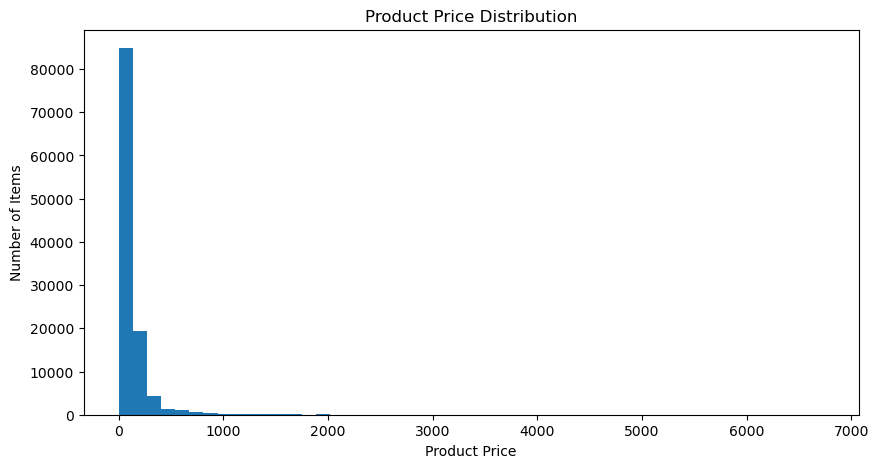

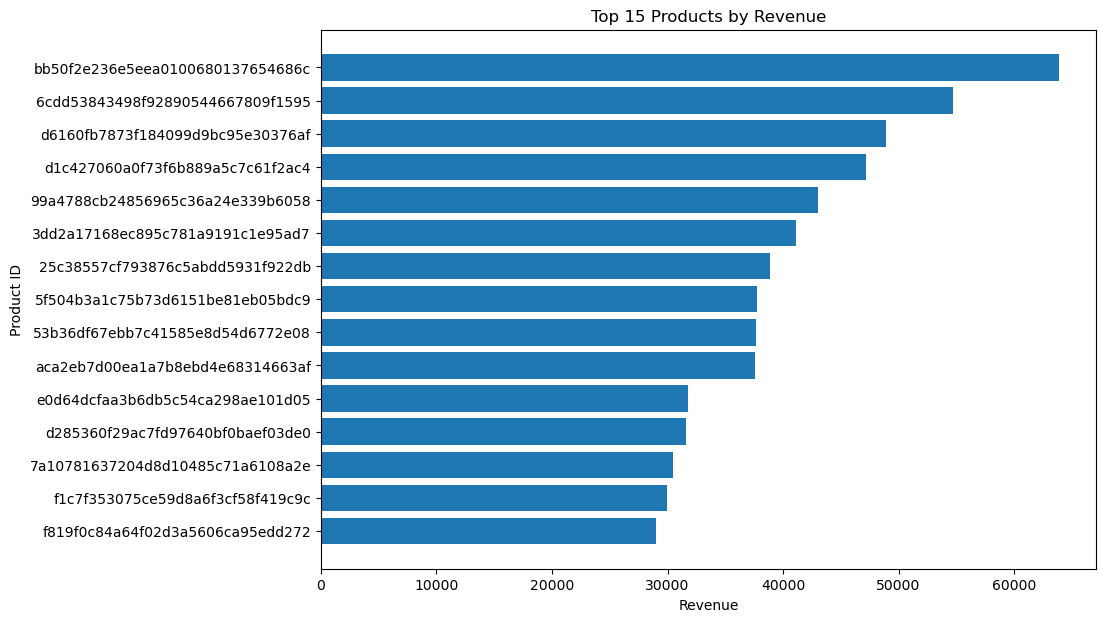

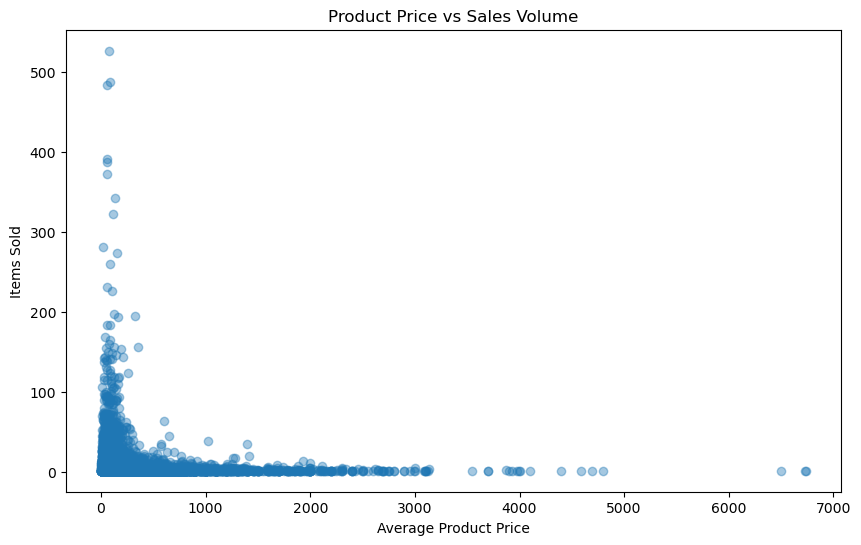

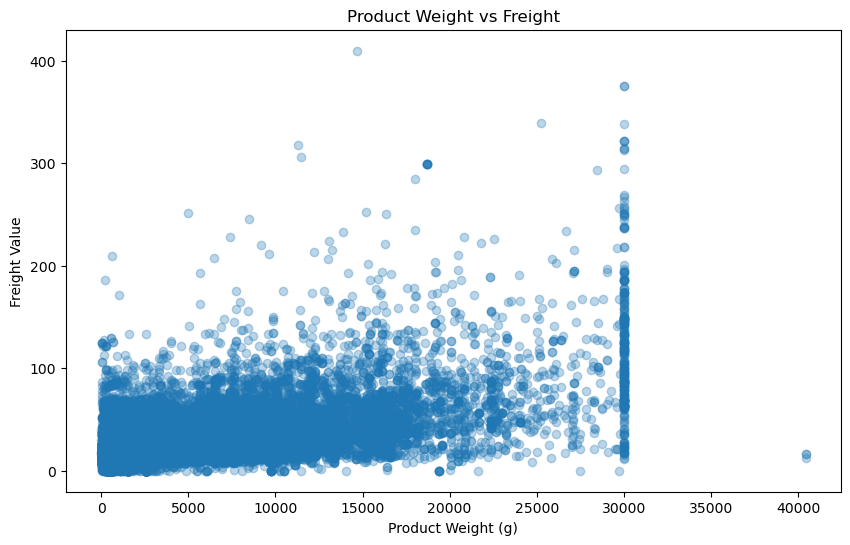


PRODUCT OPPORTUNITY ANALYSIS
                      product_id  revenue  items_sold   avg_price  avg_freight_percentage            opportunity
bb50f2e236e5eea0100680137654686c 63885.00         195  327.615385                5.823873        Scale / Promote
6cdd53843498f92890544667809f1595 54730.20         156  350.834615                7.958310        Scale / Promote
d6160fb7873f184099d9bc95e30376af 48899.34          35 1397.124000                2.936822        Scale / Promote
d1c427060a0f73f6b889a5c7c61f2ac4 47214.51         343  137.651633               29.605032 Logistics Optimization
99a4788cb24856965c36a24e339b6058 43025.56         488   88.167131               18.798513        Scale / Promote
3dd2a17168ec895c781a9191c1e95ad7 41082.60         274  149.936496               17.355991        Scale / Promote
25c38557cf793876c5abdd5931f922db 38907.32          38 1023.876842                3.614345        Scale / Promote
5f504b3a1c75b73d6151be81eb05bdc9 37733.90          63  598.950794 

In [72]:
# ============================================================
# MODULE 16 — PRODUCT & PRICING ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 16.0 PREPARE PRODUCT-LEVEL DATA
# ------------------------------------------------------------

product_analysis = fact_sales.copy()

# Add product dimensions from products_clean
product_analysis = product_analysis.merge(
    products_clean[
        [
            "product_id",
            "product_weight_g",
            "product_length_cm",
            "product_height_cm",
            "product_width_cm"
        ]
    ],
    on="product_id",
    how="left",
    suffixes=("", "_product")
)

# Avoid duplicate dimension columns if they already exist
for col in [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]:
    duplicate_col = col + "_product"

    if duplicate_col in product_analysis.columns:
        product_analysis[col] = product_analysis[col].fillna(
            product_analysis[duplicate_col]
        )
        product_analysis.drop(columns=[duplicate_col], inplace=True)

# ------------------------------------------------------------
# 16.1 DERIVED PRODUCT FEATURES
# ------------------------------------------------------------

# Product volume
product_analysis["product_volume_cm3"] = (
    product_analysis["product_length_cm"]
    * product_analysis["product_height_cm"]
    * product_analysis["product_width_cm"]
)

# Freight percentage relative to item price
product_analysis["freight_percentage"] = np.where(
    product_analysis["price"] > 0,
    (product_analysis["freight_value"] / product_analysis["price"]) * 100,
    np.nan
)

# Price bands using quartiles
price_q1 = product_analysis["price"].quantile(0.25)
price_q3 = product_analysis["price"].quantile(0.75)

product_analysis["price_band"] = pd.cut(
    product_analysis["price"],
    bins=[
        -np.inf,
        price_q1,
        price_q3,
        np.inf
    ],
    labels=[
        "Low Price",
        "Medium Price",
        "High Price"
    ]
)

# Weight bands
weight_q1 = product_analysis["product_weight_g"].quantile(0.25)
weight_q3 = product_analysis["product_weight_g"].quantile(0.75)

product_analysis["weight_band"] = pd.cut(
    product_analysis["product_weight_g"],
    bins=[
        -np.inf,
        weight_q1,
        weight_q3,
        np.inf
    ],
    labels=[
        "Light",
        "Medium",
        "Heavy"
    ]
)

print("Product analysis shape:", product_analysis.shape)
print("\nColumns:")
print(product_analysis.columns.tolist())


# ============================================================
# 16.2 OVERALL PRODUCT KPIs
# ============================================================

total_product_revenue = product_analysis["price"].sum()
total_product_items = len(product_analysis)
unique_products = product_analysis["product_id"].nunique()
unique_orders = product_analysis["order_id"].nunique()
unique_categories = product_analysis["product_category_name_english"].nunique()

print("\n" + "=" * 70)
print("PRODUCT PERFORMANCE KPIs")
print("=" * 70)

print(f"Total Revenue: ${total_product_revenue:,.2f}")
print(f"Total Items Sold: {total_product_items:,}")
print(f"Unique Products: {unique_products:,}")
print(f"Unique Orders: {unique_orders:,}")
print(f"Unique Categories: {unique_categories:,}")
print(f"Average Item Price: ${product_analysis['price'].mean():,.2f}")
print(f"Median Item Price: ${product_analysis['price'].median():,.2f}")
print(f"Average Freight: ${product_analysis['freight_value'].mean():,.2f}")
print(f"Median Freight: ${product_analysis['freight_value'].median():,.2f}")


# ============================================================
# 16.3 PRODUCT-LEVEL AGGREGATION
# ============================================================

product_summary = (
    product_analysis
    .groupby("product_id")
    .agg(
        revenue=("price", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        sellers=("seller_id", "nunique"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_freight=("freight_value", "mean"),
        total_freight=("freight_value", "sum"),
        avg_freight_percentage=("freight_percentage", "mean"),
        avg_weight_g=("product_weight_g", "mean"),
        avg_volume_cm3=("product_volume_cm3", "mean")
    )
    .reset_index()
)

product_summary["revenue_share"] = (
    product_summary["revenue"]
    / product_summary["revenue"].sum()
    * 100
)

product_summary["revenue_per_seller"] = (
    product_summary["revenue"]
    / product_summary["sellers"]
)

product_summary["revenue_rank"] = (
    product_summary["revenue"]
    .rank(method="dense", ascending=False)
)

product_summary["volume_rank"] = (
    product_summary["items_sold"]
    .rank(method="dense", ascending=False)
)

print("\nProduct summary shape:", product_summary.shape)


# ============================================================
# 16.4 TOP PRODUCTS BY REVENUE
# ============================================================

top_products_revenue = (
    product_summary
    .sort_values("revenue", ascending=False)
    .head(20)
)

print("\n" + "=" * 70)
print("TOP 20 PRODUCTS BY REVENUE")
print("=" * 70)

print(
    top_products_revenue[
        [
            "product_id",
            "revenue",
            "items_sold",
            "orders",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage",
            "revenue_share"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.5 TOP PRODUCTS BY SALES VOLUME
# ============================================================

top_products_volume = (
    product_summary
    .sort_values("items_sold", ascending=False)
    .head(20)
)

print("\n" + "=" * 70)
print("TOP 20 PRODUCTS BY SALES VOLUME")
print("=" * 70)

print(
    top_products_volume[
        [
            "product_id",
            "items_sold",
            "orders",
            "revenue",
            "avg_price",
            "avg_freight"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.6 HIGHEST-VALUE PRODUCTS
# ============================================================

high_value_products = (
    product_summary[
        product_summary["avg_price"] >= product_analysis["price"].quantile(0.95)
    ]
    .sort_values("revenue", ascending=False)
)

print("\n" + "=" * 70)
print("HIGH-VALUE PRODUCTS — TOP 20")
print("=" * 70)

print(
    high_value_products.head(20)[
        [
            "product_id",
            "revenue",
            "items_sold",
            "orders",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.7 HIGH-VOLUME / LOW-PRICE PRODUCTS
# ============================================================

volume_median = product_summary["items_sold"].median()
price_median = product_summary["avg_price"].median()

high_volume_low_price = product_summary[
    (product_summary["items_sold"] >= volume_median) &
    (product_summary["avg_price"] < price_median)
].sort_values(
    ["items_sold", "revenue"],
    ascending=[False, False]
)

print("\n" + "=" * 70)
print("HIGH-VOLUME / LOW-PRICE PRODUCTS")
print("=" * 70)

print(
    high_volume_low_price.head(20)[
        [
            "product_id",
            "items_sold",
            "orders",
            "revenue",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.8 HIGH-FREIGHT PRODUCTS
# ============================================================

# Minimum volume threshold prevents tiny one-off products
# from dominating the analysis.

high_freight_products = (
    product_summary[
        product_summary["items_sold"] >= 10
    ]
    .sort_values(
        "avg_freight_percentage",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("HIGH-FREIGHT PRODUCTS")
print("=" * 70)

print(
    high_freight_products.head(20)[
        [
            "product_id",
            "items_sold",
            "revenue",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.9 PRODUCT WEIGHT VS FREIGHT
# ============================================================

weight_freight = (
    product_analysis[
        product_analysis["product_weight_g"].notna() &
        product_analysis["freight_value"].notna()
    ]
    .groupby("weight_band")
    .agg(
        items=("order_item_id", "count"),
        avg_weight_g=("product_weight_g", "mean"),
        avg_freight=("freight_value", "mean"),
        median_freight=("freight_value", "median"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("WEIGHT VS FREIGHT")
print("=" * 70)

print(weight_freight.to_string(index=False))


# ============================================================
# 16.10 PRODUCT VOLUME VS FREIGHT
# ============================================================

volume_data = product_analysis[
    product_analysis["product_volume_cm3"].notna() &
    (product_analysis["product_volume_cm3"] > 0)
].copy()

volume_data["volume_band"] = pd.qcut(
    volume_data["product_volume_cm3"],
    q=4,
    labels=[
        "Small",
        "Medium",
        "Large",
        "Very Large"
    ],
    duplicates="drop"
)

volume_freight = (
    volume_data
    .groupby("volume_band", observed=True)
    .agg(
        items=("order_item_id", "count"),
        avg_volume_cm3=("product_volume_cm3", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

print("\n" + "=" * 70)
print("PRODUCT VOLUME VS FREIGHT")
print("=" * 70)

print(volume_freight.to_string(index=False))


# ============================================================
# 16.11 PRICE VS FREIGHT
# ============================================================

price_freight = (
    product_analysis
    .groupby("price_band", observed=True)
    .agg(
        items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_freight_percentage=("freight_percentage", "mean"),
        revenue=("price", "sum")
    )
    .reset_index()
)

price_freight["revenue_share"] = (
    price_freight["revenue"]
    / price_freight["revenue"].sum()
    * 100
)

print("\n" + "=" * 70)
print("PRICE VS FREIGHT")
print("=" * 70)

print(price_freight.to_string(index=False))


# ============================================================
# 16.12 CATEGORY × PRODUCT PERFORMANCE
# ============================================================

category_product = (
    product_analysis
    .groupby(
        [
            "product_category_name_english",
            "product_id"
        ]
    )
    .agg(
        revenue=("price", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_freight_percentage=("freight_percentage", "mean")
    )
    .reset_index()
)

category_product["category_rank"] = (
    category_product
    .groupby("product_category_name_english")["revenue"]
    .rank(
        method="dense",
        ascending=False
    )
)

print("\n" + "=" * 70)
print("TOP PRODUCT INSIDE EACH CATEGORY")
print("=" * 70)

top_category_products = category_product[
    category_product["category_rank"] == 1
].sort_values(
    "revenue",
    ascending=False
)

print(
    top_category_products.head(30).to_string(index=False)
)


# ============================================================
# 16.13 PRODUCTS WITH HIGH REVENUE + LOW FREIGHT
# ============================================================

revenue_median = product_summary["revenue"].median()
freight_median = product_summary["avg_freight_percentage"].median()

high_revenue_low_freight = product_summary[
    (product_summary["revenue"] >= revenue_median) &
    (product_summary["avg_freight_percentage"] <= freight_median)
].sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 70)
print("HIGH REVENUE + LOW FREIGHT PRODUCTS")
print("=" * 70)

print(
    high_revenue_low_freight.head(20)[
        [
            "product_id",
            "revenue",
            "items_sold",
            "orders",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.14 PRODUCTS WITH HIGH VOLUME + HIGH FREIGHT
# ============================================================

high_volume_high_freight = product_summary[
    (product_summary["items_sold"] >= volume_median) &
    (product_summary["avg_freight_percentage"] >= freight_median)
].sort_values(
    ["items_sold", "avg_freight_percentage"],
    ascending=[False, False]
)

print("\n" + "=" * 70)
print("HIGH VOLUME + HIGH FREIGHT PRODUCTS")
print("=" * 70)

print(
    high_volume_high_freight.head(20)[
        [
            "product_id",
            "items_sold",
            "revenue",
            "avg_price",
            "avg_freight",
            "avg_freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 16.15 PRODUCT PRICE DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("PRODUCT PRICE DISTRIBUTION")
print("=" * 70)

print(product_analysis["price"].describe())


# ============================================================
# 16.16 PRICE DISTRIBUTION PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    product_analysis["price"],
    bins=50
)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Items")

plt.show()


# ============================================================
# 16.17 TOP 15 PRODUCTS BY REVENUE — BAR CHART
# ============================================================

plot_data = (
    product_summary
    .sort_values("revenue", ascending=False)
    .head(15)
    .sort_values("revenue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["product_id"].astype(str),
    plot_data["revenue"]
)

plt.title("Top 15 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product ID")

plt.show()


# ============================================================
# 16.18 PRODUCT PRICE VS SALES VOLUME
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    product_summary["avg_price"],
    product_summary["items_sold"],
    alpha=0.4
)

plt.title("Product Price vs Sales Volume")
plt.xlabel("Average Product Price")
plt.ylabel("Items Sold")

plt.show()


# ============================================================
# 16.19 WEIGHT VS FREIGHT
# ============================================================

weight_plot = product_analysis[
    (product_analysis["product_weight_g"] > 0) &
    product_analysis["freight_value"].notna()
]

plt.figure(figsize=(10, 6))

plt.scatter(
    weight_plot["product_weight_g"],
    weight_plot["freight_value"],
    alpha=0.3
)

plt.title("Product Weight vs Freight")
plt.xlabel("Product Weight (g)")
plt.ylabel("Freight Value")

plt.show()


# ============================================================
# 16.20 FINAL PRODUCT OPPORTUNITY TABLE
# ============================================================

product_opportunities = product_summary.copy()

product_opportunities["opportunity"] = np.select(
    [
        (
            (product_opportunities["revenue"] >= revenue_median) &
            (product_opportunities["avg_freight_percentage"] <= freight_median)
        ),

        (
            (product_opportunities["items_sold"] >= volume_median) &
            (product_opportunities["avg_freight_percentage"] >= freight_median)
        ),

        (
            (product_opportunities["avg_price"] >= price_median) &
            (product_opportunities["items_sold"] < volume_median)
        )
    ],
    [
        "Scale / Promote",
        "Logistics Optimization",
        "Premium Product Review"
    ],
    default="Monitor"
)

print("\n" + "=" * 70)
print("PRODUCT OPPORTUNITY ANALYSIS")
print("=" * 70)

print(
    product_opportunities[
        [
            "product_id",
            "revenue",
            "items_sold",
            "avg_price",
            "avg_freight_percentage",
            "opportunity"
        ]
    ]
    .sort_values("revenue", ascending=False)
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 16.21 SAVE MAIN PRODUCT TABLE
# ============================================================

product_summary.to_csv(
    "../data/product_analysis.csv",
    index=False
)

product_opportunities.to_csv(
    "../data/product_opportunities.csv",
    index=False
)

print("\nProduct analysis files saved successfully.")

In [73]:
# ============================================================
# MODULE 17 — CROSS-ANALYSIS & FINAL BUSINESS STRATEGY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 17.0 PREPARE CROSS-ANALYSIS DATA
# ============================================================

cross_analysis = fact_sales.copy()

# ------------------------------------------------------------
# Add customer geography
# ------------------------------------------------------------

customer_geo = customers_clean[
    [
        "customer_id",
        "customer_city",
        "customer_state"
    ]
].copy()

cross_analysis = cross_analysis.merge(
    customer_geo,
    on="customer_id",
    how="left"
)

# ------------------------------------------------------------
# Product logistics features
# ------------------------------------------------------------

cross_analysis["product_volume_cm3"] = (
    cross_analysis["product_length_cm"]
    * cross_analysis["product_height_cm"]
    * cross_analysis["product_width_cm"]
)

cross_analysis["freight_percentage"] = np.where(
    cross_analysis["price"] > 0,
    (cross_analysis["freight_value"] / cross_analysis["price"]) * 100,
    np.nan
)

print("Cross-analysis shape:", cross_analysis.shape)


# ============================================================
# 17.1 CATEGORY × DELIVERY × CUSTOMER EXPERIENCE
# ============================================================

category_cross = (
    cross_analysis
    .groupby("product_category_name_english")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        freight=("freight_value", "sum"),
        avg_freight=("freight_value", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

category_cross["freight_percentage"] = (
    category_cross["freight"]
    / category_cross["revenue"]
    * 100
)

category_cross["revenue_share"] = (
    category_cross["revenue"]
    / category_cross["revenue"].sum()
    * 100
)

# ------------------------------------------------------------
# Add reviews at ORDER level
# ------------------------------------------------------------

review_order = (
    reviews_clean[
        [
            "order_id",
            "review_score"
        ]
    ]
    .drop_duplicates("order_id")
)

category_reviews = (
    cross_analysis[
        [
            "order_id",
            "product_category_name_english"
        ]
    ]
    .drop_duplicates()
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
    .groupby("product_category_name_english")
    .agg(
        reviewed_orders=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        one_star_rate=("review_score", lambda x: (x == 1).mean())
    )
    .reset_index()
)

category_cross = category_cross.merge(
    category_reviews,
    on="product_category_name_english",
    how="left"
)

print("\n" + "=" * 80)
print("CATEGORY CROSS-ANALYSIS")
print("=" * 80)

print(
    category_cross
    .sort_values("revenue", ascending=False)
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 17.2 HIGH-REVENUE + DELIVERY-RISK CATEGORIES
# ============================================================

revenue_median = category_cross["revenue"].median()
late_median = category_cross["late_rate"].median()

high_revenue_delivery_risk = category_cross[
    (category_cross["revenue"] >= revenue_median) &
    (category_cross["late_rate"] >= late_median)
].sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 80)
print("HIGH-REVENUE + DELIVERY-RISK CATEGORIES")
print("=" * 80)

print(
    high_revenue_delivery_risk[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "revenue_share",
            "avg_delivery_days",
            "late_rate",
            "avg_review_score",
            "one_star_rate",
            "freight_percentage"
        ]
    ].to_string(index=False)
)


# ============================================================
# 17.3 HIGH-REVENUE + HIGH-FREIGHT CATEGORIES
# ============================================================

freight_median = category_cross["freight_percentage"].median()

high_revenue_high_freight = category_cross[
    (category_cross["revenue"] >= revenue_median) &
    (category_cross["freight_percentage"] >= freight_median)
].sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 80)
print("HIGH-REVENUE + HIGH-FREIGHT CATEGORIES")
print("=" * 80)

print(
    high_revenue_high_freight[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "avg_price",
            "freight_percentage",
            "avg_freight"
        ]
    ].to_string(index=False)
)


# ============================================================
# 17.4 CATEGORY BUSINESS RISK SCORE
# ============================================================

# Percentile-based scoring
category_cross["revenue_score"] = (
    category_cross["revenue"].rank(pct=True) * 100
)

category_cross["late_score"] = (
    category_cross["late_rate"].rank(pct=True) * 100
)

category_cross["freight_score"] = (
    category_cross["freight_percentage"].rank(pct=True) * 100
)

category_cross["satisfaction_risk_score"] = (
    (1 - category_cross["avg_review_score"] / 5) * 100
)

category_cross["business_risk_score"] = (
    category_cross["late_score"] * 0.35
    + category_cross["freight_score"] * 0.30
    + category_cross["satisfaction_risk_score"] * 0.35
)

category_cross["business_risk_rank"] = (
    category_cross["business_risk_score"]
    .rank(method="dense", ascending=False)
)

print("\n" + "=" * 80)
print("CATEGORY BUSINESS RISK")
print("=" * 80)

print(
    category_cross
    .sort_values("business_risk_score", ascending=False)
    .head(20)[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "late_rate",
            "freight_percentage",
            "avg_review_score",
            "business_risk_score"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# 17.5 SELLER × REVENUE × DELIVERY RISK
# ============================================================

seller_cross = (
    cross_analysis
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        freight=("freight_value", "sum"),
        avg_freight=("freight_value", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

seller_cross["freight_percentage"] = (
    seller_cross["freight"]
    / seller_cross["revenue"]
    * 100
)

seller_cross["revenue_share"] = (
    seller_cross["revenue"]
    / seller_cross["revenue"].sum()
    * 100
)

# ------------------------------------------------------------
# Seller minimum volume threshold
# ------------------------------------------------------------

seller_cross["seller_priority"] = np.select(
    [
        (
            (seller_cross["revenue"] >= seller_cross["revenue"].quantile(0.75)) &
            (seller_cross["late_rate"] >= seller_cross["late_rate"].median())
        ),

        (
            (seller_cross["revenue"] >= seller_cross["revenue"].quantile(0.75)) &
            (seller_cross["late_rate"] < seller_cross["late_rate"].median())
        )
    ],
    [
        "High Revenue / Delivery Risk",
        "High Revenue / Strong Delivery"
    ],
    default="Monitor"
)

print("\n" + "=" * 80)
print("SELLER BUSINESS PRIORITY")
print("=" * 80)

print(
    seller_cross[
        seller_cross["orders"] >= 100
    ]
    .sort_values("revenue", ascending=False)
    .head(30)[
        [
            "seller_id",
            "revenue",
            "orders",
            "avg_price",
            "freight_percentage",
            "avg_delivery_days",
            "late_rate",
            "seller_priority"
        ]
    ]
    .to_string(index=False)
)


# ============================================================
# 17.6 HIGH-REVENUE SELLERS WITH OPERATIONAL RISK
# ============================================================

high_revenue_sellers = seller_cross[
    (seller_cross["revenue"] >= seller_cross["revenue"].quantile(0.75)) &
    (seller_cross["orders"] >= 100)
].copy()

seller_risk_median = high_revenue_sellers["late_rate"].median()

high_revenue_risk_sellers = (
    high_revenue_sellers[
        high_revenue_sellers["late_rate"] >= seller_risk_median
    ]
    .sort_values(
        ["revenue", "late_rate"],
        ascending=[False, False]
    )
)

print("\n" + "=" * 80)
print("HIGH-REVENUE SELLERS WITH DELIVERY RISK")
print("=" * 80)

print(
    high_revenue_risk_sellers[
        [
            "seller_id",
            "revenue",
            "orders",
            "freight_percentage",
            "avg_delivery_days",
            "late_rate"
        ]
    ]
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 17.7 STATE × REVENUE × DELIVERY × SATISFACTION
# ============================================================

state_cross = (
    cross_analysis
    .groupby("customer_state")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items=("order_item_id", "count"),
        avg_price=("price", "mean"),
        freight=("freight_value", "sum"),
        avg_delivery_days=("delivery_days", "mean"),
        late_rate=("is_late", "mean")
    )
    .reset_index()
)

state_cross["freight_percentage"] = (
    state_cross["freight"]
    / state_cross["revenue"]
    * 100
)

state_cross["revenue_share"] = (
    state_cross["revenue"]
    / state_cross["revenue"].sum()
    * 100
)

# ------------------------------------------------------------
# Reviews by state
# ------------------------------------------------------------

state_reviews = (
    cross_analysis[
        [
            "order_id",
            "customer_state"
        ]
    ]
    .drop_duplicates()
    .merge(
        review_order,
        on="order_id",
        how="left"
    )
    .groupby("customer_state")
    .agg(
        reviewed_orders=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        one_star_rate=("review_score", lambda x: (x == 1).mean())
    )
    .reset_index()
)

state_cross = state_cross.merge(
    state_reviews,
    on="customer_state",
    how="left"
)

print("\n" + "=" * 80)
print("STATE CROSS-ANALYSIS")
print("=" * 80)

print(
    state_cross
    .sort_values("revenue", ascending=False)
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 17.8 HIGH-REVENUE STATES WITH DELIVERY RISK
# ============================================================

state_revenue_threshold = state_cross["revenue"].median()
state_late_threshold = state_cross["late_rate"].median()

high_revenue_risk_states = state_cross[
    (state_cross["revenue"] >= state_revenue_threshold) &
    (state_cross["late_rate"] >= state_late_threshold)
].sort_values(
    "revenue",
    ascending=False
)

print("\n" + "=" * 80)
print("HIGH-REVENUE + DELIVERY-RISK STATES")
print("=" * 80)

print(
    high_revenue_risk_states[
        [
            "customer_state",
            "revenue",
            "orders",
            "revenue_share",
            "avg_delivery_days",
            "late_rate",
            "freight_percentage",
            "avg_review_score",
            "one_star_rate"
        ]
    ].to_string(index=False)
)


# ============================================================
# 17.9 DELIVERY STATUS × CUSTOMER SATISFACTION
# ============================================================

order_delivery_review = (
    orders_clean[
        [
            "order_id",
            "delivery_status",
            "is_late"
        ]
    ]
    .merge(
        review_order,
        on="order_id",
        how="inner"
    )
)

delivery_review = (
    order_delivery_review
    .groupby("delivery_status")
    .agg(
        reviewed_orders=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        one_star_rate=("review_score", lambda x: (x == 1).mean()),
        five_star_rate=("review_score", lambda x: (x == 5).mean())
    )
    .reset_index()
)

print("\n" + "=" * 80)
print("DELIVERY STATUS × CUSTOMER SATISFACTION")
print("=" * 80)

print(delivery_review.to_string(index=False))


# ============================================================
# 17.10 LATE DELIVERY × REVIEW CORRELATION
# ============================================================

review_delivery_numeric = (
    order_delivery_review[
        ["is_late", "review_score"]
    ]
    .dropna()
)

late_review_correlation = (
    review_delivery_numeric["is_late"]
    .astype(int)
    .corr(review_delivery_numeric["review_score"])
)

print("\n" + "=" * 80)
print("LATE DELIVERY × REVIEW CORRELATION")
print("=" * 80)

print(
    f"Correlation between late delivery and review score: "
    f"{late_review_correlation:.4f}"
)


# ============================================================
# 17.11 PRODUCT × CATEGORY × LOGISTICS PRESSURE
# ============================================================

product_cross = (
    cross_analysis
    .groupby(
        [
            "product_category_name_english",
            "product_id"
        ]
    )
    .agg(
        revenue=("price", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean"),
        avg_freight_percentage=("freight_percentage", "mean"),
        avg_weight_g=("product_weight_g", "mean"),
        avg_volume_cm3=("product_volume_cm3", "mean")
    )
    .reset_index()
)

# Minimum volume to avoid tiny-product noise
product_cross_filtered = product_cross[
    product_cross["items_sold"] >= 20
].copy()

product_cross_filtered["logistics_pressure_score"] = (
    product_cross_filtered["avg_freight_percentage"].rank(pct=True) * 100
)

print("\n" + "=" * 80)
print("PRODUCT LOGISTICS PRESSURE")
print("=" * 80)

print(
    product_cross_filtered
    .sort_values("avg_freight_percentage", ascending=False)
    .head(30)
    .to_string(index=False)
)


# ============================================================
# 17.12 BUSINESS OPPORTUNITY MATRIX
# ============================================================

category_cross["business_segment"] = np.select(
    [
        (
            (category_cross["revenue"] >= revenue_median) &
            (category_cross["late_rate"] < late_median) &
            (category_cross["freight_percentage"] < freight_median)
        ),

        (
            (category_cross["revenue"] >= revenue_median) &
            (category_cross["late_rate"] >= late_median)
        ),

        (
            (category_cross["revenue"] >= revenue_median) &
            (category_cross["freight_percentage"] >= freight_median)
        ),

        (
            (category_cross["revenue"] < revenue_median) &
            (category_cross["late_rate"] < late_median)
        )
    ],
    [
        "Scale / Protect",
        "Customer Experience Priority",
        "Logistics Optimization",
        "Monitor / Growth Opportunity"
    ],
    default="Monitor"
)

print("\n" + "=" * 80)
print("CATEGORY BUSINESS SEGMENTATION")
print("=" * 80)

print(
    category_cross[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "late_rate",
            "freight_percentage",
            "avg_review_score",
            "business_segment"
        ]
    ]
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)


# ============================================================
# 17.13 FINAL PRIORITY SCORE
# ============================================================

# Higher revenue + higher operational risk = higher priority
category_cross["priority_score"] = (
    category_cross["revenue"].rank(pct=True) * 40
    + category_cross["late_rate"].rank(pct=True) * 30
    + category_cross["freight_percentage"].rank(pct=True) * 30
)

final_priority_categories = (
    category_cross
    .sort_values("priority_score", ascending=False)
    .head(15)
)

print("\n" + "=" * 80)
print("FINAL BUSINESS PRIORITY CATEGORIES")
print("=" * 80)

print(
    final_priority_categories[
        [
            "product_category_name_english",
            "revenue",
            "orders",
            "late_rate",
            "freight_percentage",
            "avg_review_score",
            "priority_score"
        ]
    ].to_string(index=False)
)


# ============================================================
# 17.14 MANAGEMENT KPI SUMMARY
# ============================================================

management_kpis = {
    "Total Revenue": cross_analysis["price"].sum(),
    "Total Orders": cross_analysis["order_id"].nunique(),
    "Total Items": len(cross_analysis),
    "Average Order Value":
        cross_analysis["price"].sum()
        / cross_analysis["order_id"].nunique(),
    "Average Item Price": cross_analysis["price"].mean(),
    "Average Freight": cross_analysis["freight_value"].mean(),
    "Freight %":
        cross_analysis["freight_value"].sum()
        / cross_analysis["price"].sum()
        * 100,
    "Average Delivery Days": cross_analysis["delivery_days"].mean(),
    "Late Rate":
        cross_analysis["is_late"].mean() * 100,
    "Unique Sellers": cross_analysis["seller_id"].nunique(),
    "Unique Products": cross_analysis["product_id"].nunique(),
    "Unique Categories":
        cross_analysis["product_category_name_english"].nunique()
}

print("\n" + "=" * 80)
print("FINAL MANAGEMENT KPI SUMMARY")
print("=" * 80)

for metric, value in management_kpis.items():

    if "Rate" in metric or "%" in metric:
        print(f"{metric}: {value:.2f}%")

    elif "Revenue" in metric or "Freight" in metric or "Price" in metric or "Value" in metric:
        print(f"{metric}: ${value:,.2f}")

    elif "Days" in metric:
        print(f"{metric}: {value:.2f}")

    else:
        print(f"{metric}: {value:,.0f}")


# ============================================================
# 17.15 EXPORT FINAL ANALYTICAL TABLES
# ============================================================

category_cross.to_csv(
    "../data/final_category_analysis.csv",
    index=False
)

seller_cross.to_csv(
    "../data/final_seller_analysis.csv",
    index=False
)

state_cross.to_csv(
    "../data/final_state_analysis.csv",
    index=False
)

product_cross.to_csv(
    "../data/final_product_analysis.csv",
    index=False
)

print("\nFinal cross-analysis tables exported successfully.")


# ============================================================
# 17.16 EXECUTIVE SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("EXECUTIVE BUSINESS SUMMARY")
print("=" * 80)

print("""
1. Revenue is driven by a broad product and seller ecosystem.

2. Higher-value products generate a disproportionate share of revenue,
   while low-priced products can experience significant freight pressure.

3. Delivery performance is strongly associated with customer satisfaction.
   Late and undelivered orders receive substantially lower review scores.

4. Several high-revenue categories and sellers also show elevated
   delivery or freight risk and should receive operational attention.

5. Geographic performance varies significantly across Brazilian states.
   High-revenue states with weak delivery performance represent important
   improvement opportunities.

6. Product weight and physical volume are associated with higher freight
   costs, indicating packaging and fulfillment opportunities.

7. The strongest strategic approach is not to optimize every category or
   seller equally, but to prioritize high-revenue areas with measurable
   operational problems.
""")

Cross-analysis shape: (112650, 28)

CATEGORY CROSS-ANALYSIS
product_category_name_english    revenue  orders  items   avg_price   freight  avg_freight  avg_delivery_days  late_rate  freight_percentage  revenue_share  reviewed_orders  avg_review_score  one_star_rate
                health_beauty 1258681.34    8836   9670  130.163531 182566.73    18.879703          11.980525   0.088728           14.504603       9.260700             8771          4.180709       0.101403
                watches_gifts 1205005.68    5624   5991  201.135984 100535.93    16.781160          12.663180   0.080955            8.343191       8.865783             5576          4.065459       0.116465
               bed_bath_table 1036988.68    9417  11115   93.296327 204693.04    18.415928          12.806463   0.082771           19.739178       7.629605             9313          3.971116       0.125411
               sports_leisure  988048.97    7720   8641  114.344285 168607.51    19.512500          12.152057   0.07

In [74]:
print(len(orders_clean))
print(len(fact_sales))

99441
112650


In [75]:
!pip install mysql-connector-python sqlalchemy

   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/17.7 MB ? eta -:--:--
    --------------------------------------- 0.3/17.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/17.7 MB 873.1 kB/s eta 0:00:20
   - -------------------------------------- 0.8/17.7 MB 1.1 MB/s eta 0:00:16
   -- ------------------------------------- 1.0/17.7 MB 1.2 MB/s eta 0:00:14
   -- ------------------------------------- 1.3/17.7 MB 1.3 MB/s eta 0:00:13
   --- ------------------------------------ 1.6/17.7 MB 1.3 MB/s eta 0:00:12
   ---- ----------------------------------- 2.1/17.7 MB 1.4 MB/s eta 0:00:12
   ----- ---------------------------------- 2.4/17.7 MB 1.3 MB/s eta 0:00:12
   ----- ---------------------------------- 2.6/17.7 MB 1.4 MB/s eta 0:00:12
   ------ --------------------------------- 2.9/17.7 MB 1.4 MB/s eta 0:00:11
   ------ --------------------------------- 2.9/17.7 MB 1.4 MB/s eta 0:00:11
   ------- -------

In [76]:
import mysql.connector

password = input("Enter your MySQL root password: ")

try:
    connection = mysql.connector.connect(
        host="127.0.0.1",
        port=3306,
        user="root",
        password=password,
        database="olist_analysis"
    )

    print("✅ Connection successful!")
    connection.close()

except mysql.connector.Error as e:
    print("❌ Connection failed.")
    print("Reason:", e)

Enter your MySQL root password:  Abhijith@123


✅ Connection successful!


In [78]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# MySQL details
MYSQL_USER = "root"
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
MYSQL_DATABASE = "olist_analysis"

# Enter password privately
MYSQL_PASSWORD = input("Enter MySQL root password: ")

# Safely encode password
encoded_password = quote_plus(MYSQL_PASSWORD)

# Create connection
engine = create_engine(
    f"mysql+mysqlconnector://"
    f"{MYSQL_USER}:{encoded_password}"
    f"@{MYSQL_HOST}:{MYSQL_PORT}/"
    f"{MYSQL_DATABASE}"
)

# Test connection
with engine.connect() as connection:
    print("SQLAlchemy connection successful!")

print("Ready to load Olist data.")

Enter MySQL root password:  Abhijith@123


SQLAlchemy connection successful!
Ready to load Olist data.


In [79]:
# ============================================================
# LOAD CLEANED OLIST DATA INTO MYSQL
# ============================================================

tables_to_load = {
    "orders_clean": orders_clean,
    "products_clean": products_clean,
    "order_items_clean": order_items_clean,
    "reviews_clean": reviews_clean,
    "payments_clean": payments_clean,
    "customers_clean": customers_clean,
    "sellers_clean": sellers_clean,
    "geolocation_clean": geolocation_clean,
    "fact_sales": fact_sales
}

for table_name, df in tables_to_load.items():

    print(f"\nLoading: {table_name}")
    print(f"Rows: {len(df):,}")

    df.to_sql(
        name=table_name,
        con=engine,
        if_exists="replace",
        index=False,
        chunksize=5000,
        method="multi"
    )

    print(f"✓ {table_name} loaded successfully")


print("\n" + "=" * 60)
print("ALL CLEANED OLIST DATA LOADED INTO MYSQL")
print("=" * 60)


Loading: orders_clean
Rows: 99,441
✓ orders_clean loaded successfully

Loading: products_clean
Rows: 32,951
✓ products_clean loaded successfully

Loading: order_items_clean
Rows: 112,650
✓ order_items_clean loaded successfully

Loading: reviews_clean
Rows: 99,224
✓ reviews_clean loaded successfully

Loading: payments_clean
Rows: 103,886
✓ payments_clean loaded successfully

Loading: customers_clean
Rows: 99,441
✓ customers_clean loaded successfully

Loading: sellers_clean
Rows: 3,095
✓ sellers_clean loaded successfully

Loading: geolocation_clean
Rows: 1,000,163
✓ geolocation_clean loaded successfully

Loading: fact_sales
Rows: 112,650
✓ fact_sales loaded successfully

ALL CLEANED OLIST DATA LOADED INTO MYSQL
